# Genes

**What you'll learn.** The numbered tutorials introduce one idea at a time on a
handful of entities. This notebook is the gene *deep dive*: every distinct
gene-capable model in embpy, compared with every metric embpy ships, plus the
readouts that only exist for genes -- exon-level attention, locus geometry, and
variant context.

Genes are the one modality where embpy offers two genuinely different kinds of
model, and they disagree in an informative way:

* **Sequence models** read the DNA of the locus itself. They know nothing about
  what the gene *does*.
* **Prior-knowledge tables** are static lookups distilled from text, co-expression,
  or CRISPR screens. They know what the gene does and nothing about its sequence.

It answers four questions in order:

| Section | Question |
| --- | --- |
| [Embed](#embed-every-gene-capable-model) | which gene models exist, and what do they cost? |
| [Compare](#1-global-geometry) | do they encode the same structure? |
| [Interpret](#does-the-geometry-track-biology) | does that structure track gene biology? |
| [Read inside](#reading-a-dna-models-attention) | what is the model actually looking at? |

Prerequisites: [Comparing embeddings](03_compare_embeddings.ipynb) for the metric
definitions and [Reading a model's attention](06_attention_weights.ipynb) for the
extract-then-summarise pattern. Both are used here without re-deriving.
Variant-level work has its own notebook -- [Variant effects](variant_effects.ipynb)
-- and is only touched on at the end.

In [1]:
import json
import time
import warnings
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
from IPython.display import display

from embpy import BioEmbedder, pl, tl

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Nucleotide Transformer and GENA-LM ship custom modelling code and report a
# "newly initialised pooler" notice on load. Mean pooling never touches that
# head, so the notice is noise here; quieting it keeps the tables readable.
from transformers import logging as hf_logging

hf_logging.set_verbosity_error()

embedder = BioEmbedder(device="auto", organism="human")

## A panel built to make the models disagree

Comparison metrics need enough entities to be meaningful, and interpretation
needs *labels that are not derived from the embeddings*. So the panel is 40 human
genes in five classes of eight -- a grouping from gene biology, not from any
model.

The classes are chosen to split along the fault line described above, because a
panel every model handles identically measures nothing:

* **Paralog families** (`tubulin`, `hox`) are held together by *shared
  sequence*. Their members are duplicates of one ancestral gene, so a DNA model
  should find them easily and a knowledge table has no special advantage.
* **Pathway classes** (`glycolysis`, `interferon`, `cell_cycle`) are held together
  by *shared function*. Their members are unrelated in sequence -- glycolysis
  alone spans half a dozen unrelated folds -- so a DNA model should struggle and a
  knowledge table should do well.

That is a prediction, and the [interpretation section](#does-the-geometry-track-biology)
scores it rather than assuming it.

In [2]:
PANEL: dict[str, list[str]] = {
    # sequence-coherent: paralogs of one ancestral gene
    "tubulin":    ["TUBA1A", "TUBA1B", "TUBA1C", "TUBB", "TUBB2A", "TUBB3", "TUBB4B", "TUBB6"],
    "hox":        ["HOXA1", "HOXA2", "HOXA3", "HOXA5", "HOXA9", "HOXA10", "HOXA11", "HOXA13"],
    # function-coherent: shared pathway, unrelated sequence
    "glycolysis": ["GAPDH", "LDHA", "PKM", "ALDOA", "ENO1", "PGK1", "TPI1", "GPI"],
    "interferon": ["STAT1", "STAT2", "IRF1", "IRF9", "ISG15", "MX1", "OAS1", "IFIT1"],
    "cell_cycle": ["CDK1", "CDK2", "CCNA2", "CCNB1", "AURKA", "PLK1", "CHEK1", "BUB1"],
}

SEQUENCE_COHERENT = {"tubulin", "hox"}

symbols = [s for members in PANEL.values() for s in members]
families = [fam for fam, members in PANEL.items() for _ in members]

gene_space = ad.AnnData(
    X=np.zeros((len(symbols), 1), dtype=np.float32),
    obs=pd.DataFrame(
        {
            "symbol": symbols,
            "family": pd.Categorical(families),
            "coherence": pd.Categorical(
                ["sequence" if f in SEQUENCE_COHERENT else "function" for f in families]
            ),
        },
        index=pd.Index(symbols, name="gene"),
    ),
    var=pd.DataFrame(index=["placeholder"]),
)

print(f"{gene_space.n_obs} genes in {len(PANEL)} classes")
print(gene_space.obs.groupby(["coherence", "family"], observed=True).size().to_string())

40 genes in 5 classes
coherence  family    
function   cell_cycle    8
           glycolysis    8
           interferon    8
sequence   hox           8
           tubulin       8


## Which gene models does embpy have?

Genes are served by two families in `model_catalog`, and it is worth seeing both
before choosing anything.

In [3]:
static_catalog = embedder.model_catalog("static")
dna_catalog = embedder.model_catalog("dna")
print(f"static lookup tables: {len(static_catalog)}    DNA sequence models: {len(dna_catalog)}")
display(static_catalog)
display(dna_catalog)

static lookup tables: 9    DNA sequence models: 50


,model,family
0,crispr_gene_effect,static
1,crispr_gene_effect_1178,static
2,crispr_gene_effect_205,static
3,gene2vec,static
4,genept,static
5,genept_scaled,static
6,omics,static
7,pops,static
8,wikicrow,static


,model,family
0,alphagenome,dna
1,borzoi_v0,dna
2,borzoi_v0_mouse,dna
3,borzoi_v1,dna
4,borzoi_v1_mouse,dna
5,borzoi_v2,dna
6,borzoi_v2_mouse,dna
7,borzoi_v3,dna
8,borzoi_v3_mouse,dna
9,caduceus_ph_131k,dna


Fifty DNA keys overstates the choice considerably: most are *size, species, or
seed variants* of the same trained model, and comparing `nt_v2_50m` against
`nt_v2_500m` measures scale, not architecture. The roster below takes **one
checkpoint per distinct architecture**, which is what makes a cross-model
comparison mean anything.

| Key | Model | Why it earns a slot |
| --- | --- | --- |
| `hyenadna_small_32k` | HyenaDNA | implicit long convolutions, 32 kb context, **no attention at all** |
| `nt_v2_100m` | Nucleotide Transformer v2 | the standard 6-mer BPE transformer baseline |
| `gena_lm_bert_base` | GENA-LM | BPE-tokenised BERT from a different group and corpus |
| `caduceus_ph_131k` | Caduceus | bi-directional Mamba SSM, reverse-complement equivariant |
| `enformer_human_rough` | Enformer | the odd one out -- *supervised* on genomic tracks, not a language model |

Skipped on purpose: `hyenadna_tiny_1k/medium_160k/large_1m`, `nt_v2_50m/250m/500m`,
`nt_500m_*`, `ntv3_*`, `gena_lm_*_large/multi/bigbird` (scale, corpus and
tokeniser variants); every `*_mouse` key (this panel is human); `borzoi_*` and
`flashzoi_*` (a 524 kb-context track predictor -- it has its own notebook,
[Variant effects](variant_effects.ipynb)); `evo1*`/`evo2_*` (need a GPU and
FlashAttention); `alphagenome` (a hosted API needing a key); `scooby_*` (installs
from a git URL).

On the static side the choice is smaller and every table that *works* earns a
slot, because they are built from genuinely different evidence. That qualifier is
doing real work: the roster is now derived from embpy's own download
specification, and one advertised key still points at a file the public data
repository does not carry. The [embed section](#embed-every-gene-capable-model)
checks that rather than glossing over it.

`get_model(..., load=False)` reads a wrapper's declared capabilities without
downloading weights, which is how the table below can mention a 40B checkpoint
cheaply.

In [4]:
DNA_ROSTER = ["hyenadna_small_32k", "nt_v2_100m", "gena_lm_bert_base",
              "caduceus_ph_131k", "enformer_human_rough"]

rows = []
for key in DNA_ROSTER + ["borzoi_v0", "evo2_40b", "alphagenome", "scooby_neurips"]:
    try:
        w = embedder.get_model(key, load=False)
        rows.append({"model": key, "wrapper": type(w).__name__,
                     "has_attention": w.has_attention, "status": "available"})
    except Exception as exc:
        rows.append({"model": key, "wrapper": "-", "has_attention": None,
                     "status": f"{type(exc).__name__}"})

display(pd.DataFrame(rows).set_index("model"))

,wrapper,has_attention,status
model,,,
hyenadna_small_32k,HyenaDNAWrapper,False,available
nt_v2_100m,NucleotideTransformerWrapper,True,available
gena_lm_bert_base,GENALMWrapper,True,available
caduceus_ph_131k,CaduceusWrapper,False,available
enformer_human_rough,EnformerWrapper,False,available
borzoi_v0,BorzoiWrapper,False,available
evo2_40b,Evo2Wrapper,False,available
alphagenome,AlphaGenomeWrapper,True,available
scooby_neurips,ScoobyWrapper,True,available


`has_attention` is a class attribute, so that column costs nothing to read -- and
it is already telling you where the [attention section](#reading-a-dna-models-attention)
can go. **HyenaDNA and Caduceus report `False` by construction**: one is built
from implicit long convolutions and the other from a state-space model, so
neither computes an attention matrix that could be extracted. That is a property
of the architecture, not a gap in embpy. `docs/attention_extraction.md` records
the per-model reasoning.

## Resolve the loci, and measure them before trusting anything

A protein is a sequence. A gene is not -- not until you say *which* sequence you
mean. Three candidates exist for every gene in the panel and they are not close
to interchangeable:

* the **full locus**, promoter to terminator, introns included;
* the **spliced exons**, concatenated -- what the transcript is made of;
* the **introns** alone, which is what you would use to ask about regulation.

The choice matters because DNA models have hard context limits and loci are
mostly intron. `GeneResolver.get_gene_regions(..., region="exons")` exists for
exactly this reason, and the geometry cell below measures the ratio that
justifies it rather than quoting it.

The fetch is the expensive part. `get_gene_regions` makes **one Ensembl REST call
per exon**, so a gene with thirty exons is thirty round trips, and Ensembl
intermittently returns a 500 under load. Two consequences shape the code below:

1. **Cache to disk, incrementally.** Write the cache back after *every* gene, so
   a failure at gene 31 does not discard the first thirty.
2. **Take the coordinates from the same call as the sequence.** Each returned
   region carries `start`/`end` alongside `sequence`, so the locus span is free.
   Fetching it separately would be a second round trip for data already in hand.

There is a third consequence, and it used to be the one that bit hardest. **A
timed-out exon was dropped silently.** `_fetch_region_sequence` catches the
request exception, logs a warning and returns `None`; `get_gene_regions` then
appended only the regions that came back truthy. So a transient network blip did
not raise -- it returned a *shorter gene*. Observed while writing this notebook:

```
WARNING:root:Failed to fetch sequence 6:30722918-30723028: Read timed out
WARNING:root:Failed to fetch sequence 6:30723340-30725422: Read timed out
TUBB   2 exons    321 bp
```

TUBB has four exons and about 2,500 bp. Two of them vanished, the call returned
successfully, and the only signal was a log line that nothing reads. An embedding
computed from that string looks entirely normal -- right dimensionality, sensible
norm, plausible neighbours -- and is wrong.

`get_gene_regions` now refuses to do that: if any exon fetch fails it logs an
error naming the exon and returns `None`, because a caller can retry a `None` but
cannot detect a short sequence. The cell below keeps its own check anyway, and the
belt-and-braces is deliberate -- it asks Ensembl how many exons the canonical
transcript *has* before fetching, so a gene where the annotation itself disagrees
with the sequence server is distinguishable from a network failure, and the cache
on disk carries a `complete` flag rather than being trusted because it exists.
One extra lookup per gene against dozens of per-exon calls is a good trade.

In [5]:
import requests

from embpy.resources.gene.resolver import GeneResolver

# species=, not organism= -- the constructor and the per-call argument disagree
# on spelling, and passing organism= here is a TypeError.
resolver = GeneResolver(species="human", auto_download=False)

CACHE_PATH = OUTPUT_DIR / "gene_exons.json"
try:
    _raw_cache = json.loads(CACHE_PATH.read_text()) if CACHE_PATH.exists() else {}
except Exception as exc:            # a half-written cache is a nuisance, not a stop
    print(f"cache unreadable ({type(exc).__name__}), starting empty: {CACHE_PATH}")
    _raw_cache = {}

# Only entries that passed the completeness check below are reused. An entry written
# by an older run has no "complete" flag, so it cannot be distinguished from a
# truncated fetch and is re-fetched rather than trusted -- which is why the count of
# rejected entries is printed rather than hidden.
exon_cache: dict[str, dict] = {k: v for k, v in _raw_cache.items() if v.get("complete")}
unvalidated = [s for s in symbols if s in _raw_cache and s not in exon_cache]
cached_at_start = sum(1 for s in symbols if s in exon_cache)
print(f"exon cache: {cached_at_start}/{len(symbols)} panel genes already on disk "
      f"({CACHE_PATH})")
if unvalidated:
    print(f"  {len(unvalidated)} cached entr(ies) carry no completeness flag and will "
          f"be re-fetched: {', '.join(unvalidated[:8])}")


def canonical_transcript(symbol: str) -> dict:
    # The gene record that says how many exons the answer *should* have. This is the
    # same lookup get_gene_regions makes internally; asking for it up front is what
    # lets the caller tell a complete fetch from a truncated one.
    resp = requests.get(
        f"https://rest.ensembl.org/lookup/symbol/homo_sapiens/{symbol}?expand=1",
        headers={"Content-Type": "application/json"}, timeout=60,
    )
    resp.raise_for_status()
    transcripts = resp.json().get("Transcript", [])
    if not transcripts:
        raise RuntimeError("Ensembl returned no transcripts")
    return next((t for t in transcripts if t.get("is_canonical") == 1), transcripts[0])


def fetch_exons(symbol: str, attempts: int = 3) -> dict:
    # One resolver call gives both the exon sequences and their coordinates, so the
    # locus span costs nothing extra. The expected count is one extra lookup, and it
    # is the whole reason this function can be trusted -- see the note above.
    tx = canonical_transcript(symbol)
    n_expected = len(tx.get("Exon", []))
    got = 0
    for attempt in range(attempts):
        regions = resolver.get_gene_regions(symbol, id_type="symbol",
                                            organism="human", region="exons")
        if regions and len(regions) == n_expected and all(str(r["sequence"]) for r in regions):
            starts = [int(r["start"]) for r in regions]
            ends = [int(r["end"]) for r in regions]
            return {
                "chrom": str(regions[0]["seq_region_name"]),
                "strand": int(regions[0]["strand"]),
                "transcript": tx.get("id", ""),
                "n_exons": len(regions),
                "exon_lengths": [len(str(r["sequence"])) for r in regions],
                "span": max(ends) - min(starts) + 1,
                "sequence": "".join(str(r["sequence"]) for r in regions),
                "complete": True,
            }
        got = len(regions) if regions else 0
        print(f"  {symbol}: got {got}/{n_expected} exons "
              f"(attempt {attempt + 1}/{attempts}) -- retrying")
    raise RuntimeError(f"only {got}/{n_expected} exons after {attempts} attempts")


t0 = time.perf_counter()
fetched, failures = [], {}
for symbol in symbols:
    if symbol in exon_cache:
        continue
    t_gene = time.perf_counter()
    try:
        record = fetch_exons(symbol)
        exon_cache[symbol] = record
        fetched.append(symbol)
        # Write after each gene: a mid-run Ensembl 500 then costs one gene, not all.
        CACHE_PATH.write_text(json.dumps(exon_cache))
        print(f"  {symbol:<8} {record['n_exons']:>3} exons  "
              f"{len(record['sequence']):>6,} bp  "
              f"{time.perf_counter() - t_gene:5.1f}s")
    except Exception as exc:
        failures[symbol] = f"{type(exc).__name__}: {str(exc)[:80]}"
        print(f"  {symbol:<8} failed after {time.perf_counter() - t_gene:.1f}s -- "
              f"{failures[symbol]}")

elapsed = time.perf_counter() - t0
resolved = [s for s in symbols if s in exon_cache]
print(f"\n{len(resolved)}/{len(symbols)} resolved  "
      f"({cached_at_start} from cache, {len(fetched)} from the network) "
      f"in {elapsed:.1f}s")
if failures:
    print(f"{len(failures)} gene(s) unresolved: {sorted(failures)}")

exon cache: 0/40 panel genes already on disk (outputs/gene_exons.json)


  TUBA1A     4 exons   1,672 bp   27.6s


  TUBA1B     4 exons   1,627 bp   25.6s


  TUBA1C     4 exons   2,823 bp   23.1s


  TUBB       4 exons   2,515 bp   78.6s


...

  AURKA: got 0/9 exons (attempt 1/3) -- retrying


  AURKA      9 exons   2,033 bp   65.4s


  PLK1      10 exons   2,160 bp   31.6s


  CHEK1     13 exons   4,128 bp   42.8s


  BUB1      25 exons   3,762 bp   33.7s

40/40 resolved  (0 from cache, 40 from the network) in 2099.1s


Two things about that cache are worth stating plainly rather than discovering
later.

**It is a cache of one particular reading of each gene.** `get_gene_regions`
picks the *canonical* transcript -- the cache records which one -- and fetches
each exon on the gene's own strand, but concatenates the exons in ascending
genomic-coordinate order. For a minus-strand gene that is the reverse of
transcription order, so the string is not the mature mRNA. The next cell counts
how many panel genes that applies to. Every gene is treated identically, so the
cross-model comparison stays fair -- but do not read these vectors as transcript
embeddings.

**A gene that fails to resolve is not dropped from the notebook.** The static
lookup tables need only a symbol, so an unresolved gene still gets a row in every
static space. It only leaves the DNA half. The `has_sequence` column below is
the switch, and every DNA cell filters on it.

In [6]:
gene_space.obs["has_sequence"] = [s in exon_cache for s in symbols]
gene_space.obs["exon_len"] = [
    len(exon_cache[s]["sequence"]) if s in exon_cache else np.nan for s in symbols
]
gene_space.obs["n_exons"] = [
    exon_cache[s]["n_exons"] if s in exon_cache else np.nan for s in symbols
]
gene_space.obs["locus_span"] = [
    exon_cache[s]["span"] if s in exon_cache else np.nan for s in symbols
]
gene_space.obs["span_ratio"] = gene_space.obs["locus_span"] / gene_space.obs["exon_len"]

geom = gene_space.obs.loc[gene_space.obs["has_sequence"]]
if geom.empty:
    print("no gene resolved -- the geometry summary and the DNA sweep below have "
          "nothing to run on, and every DNA cell will report that and continue")

print(f"exon length   : min {geom['exon_len'].min():,.0f}  "
      f"median {geom['exon_len'].median():,.0f}  max {geom['exon_len'].max():,.0f} bp")
print(f"locus span    : min {geom['locus_span'].min():,.0f}  "
      f"median {geom['locus_span'].median():,.0f}  max {geom['locus_span'].max():,.0f} bp")
print(f"span / exon   : median {geom['span_ratio'].median():.1f}x  "
      f"max {geom['span_ratio'].max():.1f}x")

n_minus = sum(1 for s in resolved if exon_cache[s].get("strand") == -1)
print(f"minus strand  : {n_minus}/{len(resolved)} genes -- exons concatenated in "
      f"genomic order, so reversed relative to transcription\n")

print("five widest loci:")
display(geom.nlargest(5, "locus_span")[
    ["family", "n_exons", "exon_len", "locus_span", "span_ratio"]].round(1))

exon length   : min 637  median 2,200  max 5,015 bp
locus span    : min 1,044  median 9,342  max 45,574 bp
span / exon   : median 3.2x  max 15.1x
minus strand  : 19/40 genes -- exons concatenated in genomic order, so reversed relative to transcription

five widest loci:


,family,n_exons,exon_len,locus_span,span_ratio
gene,,,,,
HOXA3,hox,6,3026,45574,15.1
STAT1,interferon,25,4116,45023,10.9
BUB1,cell_cycle,25,3762,40536,10.8
GPI,glycolysis,18,4125,37218,9.0
MX1,interferon,17,2776,32974,11.9


The `span_ratio` column is the whole argument for `region="exons"` in one number.
A gene whose locus is an order of magnitude longer than its exons spends that
order of magnitude on introns -- and feeding the full locus to a model with a
fixed context window means most of the window is intron, or the sequence does not
fit at all.

The panel's own spans decide how much of a problem that is. Take HyenaDNA's
32,768 bp context as the yardstick. It is the longest context among the DNA
*language models* the sweep below is expected to get through -- Caduceus is
nominally longer at 131 kb, but it needs a dependency this environment may not
have, and the sweep reports what actually happened instead of assuming it. So
this is the friendly case. (Enformer's window is six times longer again, but it
is not a language model and not a fair comparison; the
[subsection below](#why-enformer-is-not-in-the-sweep) measures why.)

In [7]:
HYENADNA_CONTEXT = 32_768   # the '32k' in hyenadna_small_32k

over_locus = geom[geom["locus_span"] > HYENADNA_CONTEXT]
over_exons = geom[geom["exon_len"] > HYENADNA_CONTEXT]

print(f"of {len(geom)} resolved genes:")
print(f"  {len(over_locus):>2} have a full locus longer than {HYENADNA_CONTEXT:,} bp")
print(f"  {len(over_exons):>2} have exons longer than {HYENADNA_CONTEXT:,} bp")

if len(over_locus):
    print("\nwidest loci that overflow a 32 kb context:")
    display(over_locus.nlargest(min(8, len(over_locus)), "locus_span")[
        ["family", "exon_len", "locus_span", "span_ratio"]].round(1))

n_fit = len(geom) - len(over_exons)
print(f"\nSo: exons for the sweep. {n_fit}/{len(geom)} spliced sequences fit inside "
      f"{HYENADNA_CONTEXT:,} bp.")
if len(over_exons):
    print(f"The other {len(over_exons)} exceed it. Nothing is discarded -- the batch path "
          "splits an over-long input into context-sized chunks and mean-pools the chunk "
          "vectors -- but those rows are an average over chunks, not one forward pass.")

of 40 resolved genes:
   5 have a full locus longer than 32,768 bp
   0 have exons longer than 32,768 bp

widest loci that overflow a 32 kb context:


,family,exon_len,locus_span,span_ratio
gene,,,,
HOXA3,hox,3026,45574,15.1
STAT1,interferon,4116,45023,10.9
BUB1,cell_cycle,3762,40536,10.8
GPI,glycolysis,4125,37218,9.0
MX1,interferon,2776,32974,11.9



So: exons for the sweep. 40/40 spliced sequences fit inside 32,768 bp.


## Embed every gene-capable model

Two families, and they are not variations on a theme.

### The static tables: eight lookups, six distinct sources

Every one of these is a **precomputed table**, keyed by gene identifier and
downloaded from `theislab/Embpy_Data`. That is the important property. A lookup
cannot generalise: a gene absent from the table has no vector, and no amount of
compute will produce one. This is why `missing="nan"` is not optional below --
with the default `missing="error"` a single unlisted gene aborts the call.

The evidence each one is distilled from decides what it can possibly know:

| Key | Distilled from | Keyed by | Therefore knows | Therefore cannot know |
| --- | --- | --- | --- | --- |
| `genept` | GPT-3.5 embeddings of NCBI gene summary text | Ensembl ID | what has been *written* about the gene | anything not yet curated into a summary |
| `genept_scaled` | the same text embeddings, z-scored | symbol | the same, on a comparable scale | the same blind spot |
| `gene2vec` | co-expression across GEO | Ensembl ID | which genes move together across experiments | causality, or anything about un-profiled genes |
| `crispr_gene_effect_1178` | DepMap CRISPR knockout fitness, 1178-d | symbol | which genes are needed by which cell lines | genes never screened, and non-fitness function |
| `crispr_gene_effect_205` | the same screen, 205-d | symbol | the same signal, compressed | the same |
| `omics` | a 256-d omics feature table -- the source spec says no more than that | Ensembl ID | whatever those features measure | it is the one row here you cannot reason about from provenance |
| `pops` | PoPS polygenic priority features, 256-d | Ensembl ID | GWAS-informed trait relevance | anything about genes without association data |
| `wikicrow` | LLM-written gene review articles | symbol | a longer-form written account than GenePT's | the same text-derived limits, one generation removed |

Two of these are *text about the gene*, two are the *same* CRISPR screen at two
widths, and the rest are separate measurements. That mixture is deliberate: the
[comparison section](#1-global-geometry) should show text tables agreeing with
each other more than they agree with the screens, and the key column above is
the reason to expect different coverage gaps for `genept` and `genept_scaled`
even though the numbers behind them are the same.

### What the catalogue promises, and what it can deliver

`model_catalog("static")` used to advertise eleven gene keys, three of which
could not be loaded at all: `ccle` and `ccle_ensembl` had no source specification
behind them, and `crispr_gene_effect` had one pointing at a file the public data
repository does not ship. `embed()` got as far as the download and raised
`FileNotFoundError`.

The cause was three lists with no agreement between them --
`DEFAULT_STATIC_EMBEDDING_MODELS` (a hand-written `frozenset` in
`embpy/embedder.py`), the source specification table (`_DEFAULT_SOURCE_SPECS` in
`embpy/pp/static_embeddings.py`) and the contents of the repository itself. The
roster is now *derived* from the specification table, so the first two cannot
drift apart again; the cell below checks that invariant rather than trusting it.

What derivation cannot fix is the third list. A key is advertised when embpy knows
which file to ask for, which is not the same as the repository serving it:
`crispr_gene_effect` wants the raw DepMap matrix, and the public repository only
carries the two reduced versions. That failure is still real, and still worth
seeing.

The STRING tables in the same specification file are a separate matter. They
declare `entity_type="protein"` and are keyed by STRING protein identifiers, so
they are deliberately *not* in the gene roster -- offering them here would make
the loader try to resolve some nineteen thousand `9606.ENSP...` identifiers into
gene symbols one request at a time.
One cell to record it, then on with the sweep.

In [8]:
from embpy.embedder import DEFAULT_STATIC_EMBEDDING_MODELS
from embpy.pp.static_embeddings import static_embedding_keys

advertised = set(embedder.model_catalog("static")["model"])
print(f"advertised gene lookups : {len(advertised)}")
print(f"derived from the specs  : {advertised == static_embedding_keys('gene')}")
print(f"retired phantom keys    : {sorted({'ccle', 'ccle_ensembl'} & advertised) or 'none'}")
print(f"protein-keyed tables    : {sorted(static_embedding_keys('protein'))}"
      "  <- correctly absent from the gene roster\n")

# Two instructive failures: a key whose file the public repo does not carry, and a
# protein table asked for as though it were a gene table.
for key in ["crispr_gene_effect", "string_functional_9606"]:
    try:
        embedder.embed(gene_space.copy(), entity_type="gene", id_type="symbol",
                       obs_column="symbol", model=key, output="anndata",
                       is_perturbation=True, key="X_probe", missing="nan")
        print(f"{key:<24} unexpectedly worked")
    except Exception as exc:
        print(f"{key:<24} {type(exc).__name__}: {str(exc)[:110]}")

advertised gene lookups : 9
derived from the specs  : True
retired phantom keys    : none
protein-keyed tables    : ['string_functional_9606', 'string_node2vec_9606']  <- correctly absent from the gene roster



ERROR:root:Failed to load text model 'string_functional_9606': string_functional_9606 is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`


crispr_gene_effect       FileNotFoundError: Embeddings for 'crispr_gene_effect' not found. Available: ['crispr_gene_effect_1178', 'crispr_gene_effect_1178
string_functional_9606   ModelNotFoundError: Model 'string_functional_9606' could not be loaded from Hugging Face and is not in the predefined registry. Av


### The static sweep

One `embed` call per working table. Each writes its own `.obsm` key, and because
these are lookups rather than inference the cost is a download plus an index
join -- seconds, not minutes, and no model cache to clear.

`is_perturbation=True` is what sends the matrix to `.obsm` instead of `.varm`.
embpy treats gene embeddings as *feature* embeddings by default, which is right
when genes are the columns of an expression matrix and wrong here, where each
gene is a row in its own right.

In [9]:
STATIC_ROSTER = ["genept", "genept_scaled", "gene2vec",
                 "crispr_gene_effect_1178", "crispr_gene_effect_205",
                 "omics", "pops", "wikicrow"]

spaces: dict[str, str] = {}
static_rows = []

for key in STATIC_ROSTER:
    obsm_key = f"X_{key}"
    t0 = time.perf_counter()
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            gene_space = embedder.embed(
                gene_space, entity_type="gene", id_type="symbol",
                obs_column="symbol", model=key, output="anndata",
                is_perturbation=True, key=obsm_key, missing="nan",
            )
        matrix = np.asarray(gene_space.obsm[obsm_key], dtype=float)
        gaps = [s for s, bad in zip(gene_space.obs_names, np.isnan(matrix).all(axis=1)) if bad]
        # A table that covers none of the panel is not a usable space: registering it
        # would make the all-spaces intersection below empty for everyone else.
        status = "ok" if len(gaps) < matrix.shape[0] else "skipped -- covers no panel gene"
        if len(gaps) < matrix.shape[0]:
            spaces[key] = obsm_key
        static_rows.append({"model": key, "dim": matrix.shape[1],
                            "seconds": round(time.perf_counter() - t0, 1),
                            "n_missing": len(gaps),
                            "missing": ", ".join(gaps) if gaps else "-",
                            "status": status})
    except Exception as exc:
        static_rows.append({"model": key, "dim": None,
                            "seconds": round(time.perf_counter() - t0, 1),
                            "n_missing": None, "missing": "-",
                            "status": f"skipped -- {type(exc).__name__}: {str(exc)[:50]}"})

display(pd.DataFrame(static_rows).set_index("model"))

Fetching 25 files:   0%|          | 0/25 [00:00<?, ?it/s]

Fetching 24 files:   0%|          | 0/24 [00:00<?, ?it/s]

Fetching 25 files:   0%|          | 0/25 [00:00<?, ?it/s]

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

Fetching 24 files:   0%|          | 0/24 [00:00<?, ?it/s]

Fetching 25 files:   0%|          | 0/25 [00:00<?, ?it/s]

Fetching 24 files:   0%|          | 0/24 [00:00<?, ?it/s]

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

,dim,seconds,n_missing,missing,status
model,,,,,
genept,3072,1.4,3,"TUBB, LDHA, GPI",ok
genept_scaled,3072,0.7,0,-,ok
gene2vec,200,0.5,0,-,ok
crispr_gene_effect_1178,1178,0.6,2,"TUBA1A, TUBA1C",ok
crispr_gene_effect_205,205,0.7,0,-,ok
omics,256,0.5,0,-,ok
pops,256,0.5,1,PGK1,ok
wikicrow,4096,0.7,2,"TUBB4B, PLK1",ok


Read the `n_missing` column as a property of the *table*, not of the gene. A
`NaN` row means the table was built without that gene, which is a coverage
statement about the underlying resource -- which cell lines DepMap screened,
which genes have a curated NCBI summary, which have GWAS signal. It is not a
model failing to compute an answer; there was never an answer to look up.

That matters downstream because several of the comparison metrics take a
distance over rows, and a `NaN` row poisons every distance it touches. The
[end of this section](#one-gene-space-two-views) deals with it explicitly rather
than letting it propagate.

### The DNA sweep

The DNA models take a sequence, so the exons resolved above are the input. Two
practical decisions:

* **Resolve once, embed many.** Passing gene symbols to `embed` would make the
  resolver run again for every model, multiplying an already slow fetch by the
  number of models. The cached exon strings go in directly via
  `entity_type="sequence"`.
* **`clear_model_cache()` between models.** embpy caches wrappers, which is right
  when you re-embed and wrong when you sweep -- three checkpoints resident at
  once for no benefit. Dropping each after use keeps the peak at one model.

One wrinkle in the sequence path is worth knowing before it surprises you. When
`entity_type="sequence"`, the entity *identity* is the sequence string itself, so
embpy cannot re-index the result onto rows named by gene symbol -- attaching to
`gene_space` directly raises `Cannot auto-resolve attach axis`. The call below
therefore embeds a plain list and gets a standalone AnnData back, whose
`.obs["original_sequence"]` column is used to put the rows where they belong.

`caduceus_ph_131k` is in the loop on purpose. Its state-space backbone needs
`mamba_ssm`, which is not part of this environment's install, so it is the
expected skip case -- the loop prints whatever the failure actually is rather
than asserting it in advance, and carries on to the next model.

In [10]:
DNA_SWEEP = ["hyenadna_small_32k", "nt_v2_100m", "gena_lm_bert_base", "caduceus_ph_131k"]

dna_genes = [s for s in symbols if s in exon_cache]
dna_sequences = [exon_cache[s]["sequence"] for s in dna_genes]
row_of = {s: i for i, s in enumerate(gene_space.obs_names)}
if dna_genes:
    print(f"embedding {len(dna_genes)} genes "
          f"({sum(len(q) for q in dna_sequences):,} bp of spliced sequence in total)\n")
else:
    print("no resolved sequences -- the DNA sweep has nothing to embed\n")

dna_rows = []
for key in (DNA_SWEEP if dna_genes else []):
    obsm_key = f"X_{key}"
    t0 = time.perf_counter()
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            out = embedder.embed(
                dna_sequences, entity_type="sequence", id_type="sequence",
                model=key, output="anndata", key=obsm_key, pooling_strategy="mean",
            )
        matrix = np.asarray(out.obsm[obsm_key], dtype=float)

        # Re-order defensively. The returned rows have followed input order every
        # time here, but the check costs nothing and a silent mis-alignment would be
        # invisible in every metric downstream. Anything the check cannot repair is
        # raised, so the model is reported as skipped rather than quietly scrambled.
        returned = [str(s) for s in out.obs.get("original_sequence", [])]
        if returned and returned != dna_sequences:
            if sorted(returned) != sorted(dna_sequences):
                raise RuntimeError(
                    f"returned {len(returned)} rows for {len(dna_sequences)} sequences"
                )
            pos = {seq: i for i, seq in enumerate(returned)}
            matrix = matrix[[pos[seq] for seq in dna_sequences]]
        elif matrix.shape[0] != len(dna_sequences):
            raise RuntimeError(
                f"returned {matrix.shape[0]} rows for {len(dna_sequences)} sequences"
            )

        full = np.full((gene_space.n_obs, matrix.shape[1]), np.nan, dtype=np.float32)
        for symbol, row in zip(dna_genes, matrix):
            full[row_of[symbol]] = row
        gene_space.obsm[obsm_key] = full

        spaces[key] = obsm_key
        dna_rows.append({"model": key, "dim": matrix.shape[1],
                         "seconds": round(time.perf_counter() - t0, 1),
                         "n_missing": gene_space.n_obs - len(dna_genes),
                         "status": "ok"})
    except Exception as exc:
        dna_rows.append({"model": key, "dim": None,
                         "seconds": round(time.perf_counter() - t0, 1),
                         "n_missing": None,
                         "status": f"skipped -- {type(exc).__name__}: {str(exc)[:70]}"})
    finally:
        embedder.clear_model_cache()

# Named columns so an empty sweep still produces a table rather than a KeyError.
display(pd.DataFrame(dna_rows, columns=["model", "dim", "seconds", "n_missing",
                                        "status"]).set_index("model"))

embedding 40 genes (100,191 bp of spliced sequence in total)



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


ERROR:root:Failed to load model 'caduceus_ph_131k' using wrapper CaduceusWrapper and path 'kuleshov-group/caduceus-ph_seqlen-131k_d_model-256_n_layer-16': Could not load Caduceus 'kuleshov-group/caduceus-ph_seqlen-131k_d_model-256_n_layer-16'.


,dim,seconds,n_missing,status
model,,,,
hyenadna_small_32k,256.0,15.2,0.0,ok
nt_v2_100m,512.0,119.3,0.0,ok
gena_lm_bert_base,768.0,46.0,0.0,ok
caduceus_ph_131k,NaN,3.8,NaN,skipped -- ModelLoadError: Failed to load mode...


The `seconds` column is not a throughput benchmark and should not be read as one.
It mixes a one-off checkpoint download on a model's first ever run with the
inference itself, and the three models tokenise the same DNA into very different
numbers of tokens -- HyenaDNA is single-nucleotide, NT v2 emits roughly one token
per 6 bp, GENA-LM uses BPE -- so a shared bp count is not a shared token count.
The [attention section](#reading-a-dna-models-attention) measures the token
counts directly on one sequence.

One shared mechanism does apply to all three. `_hf_batched_embed` tokenises each
input *without* truncation, splits it into context-sized chunks, embeds every
chunk and mean-pools the chunk vectors, so an over-long sequence costs more
forward passes rather than losing its tail. That is worth knowing for reasons
beyond timing: a gene whose exons overflow the context gets a vector averaged
over several partial views of itself, which is not quite the same object as a
short gene's single-pass vector.

`n_missing` is identical across DNA rows by construction: it is the count of
panel genes that never resolved, and they are the same genes for every DNA model
because they all read the same cache.

### Why Enformer is not in the sweep

Enformer is on the roster in [part 1](#which-gene-models-does-embpy-have) and it
is deliberately *not* in the loop above. It is not a question of cost. Enformer
is a supervised track predictor with a **fixed 196,608 bp input window**, and
`EnformerWrapper._preprocess_sequence` centre-pads or centre-crops whatever you
give it to exactly that length. Hand it a few kilobases of spliced exons and
almost the entire window is padding.

That is measurable, so measure it rather than asserting it. `_preprocess_sequence`
is private and reaching into it is the point here -- it is the step that would
otherwise happen invisibly inside `embed`.

In [11]:
if dna_genes:
    probe_symbol = dna_genes[0]
    probe_seq = exon_cache[probe_symbol]["sequence"]
    try:
        enformer = embedder.get_model("enformer_human_rough")
        one_hot = enformer._preprocess_sequence(probe_seq)   # (1, window, 4)
        window = enformer.SEQUENCE_LENGTH
        informative = int((one_hot.sum(dim=-1) > 0).sum().item())

        print(f"one-hot shape           : {tuple(one_hot.shape)}")
        print(f"Enformer input window   : {window:,} bp")
        print(f"{probe_symbol} spliced exons".ljust(24) + f": {len(probe_seq):,} bp")
        print(f"rows carrying a base    : {informative:,}")
        print(f"blank rows              : {(window - informative) / window:.2%} of the window")
    except Exception as exc:
        print(f"Enformer probe skipped -- {type(exc).__name__}: {str(exc)[:110]}")
    finally:
        embedder.clear_model_cache()
else:
    print("no resolved sequences, skipping the Enformer probe")

one-hot shape           : (1, 196608, 4)
Enformer input window   : 196,608 bp
TUBA1A spliced exons    : 1,672 bp
rows carrying a base    : 1,672
blank rows              : 99.15% of the window


Padding is encoded as an all-zero one-hot row, and so is any `N` inside the
sequence itself -- neither maps to a base -- so the count above is "positions
carrying a base" and the fraction is the share of Enformer's receptive field
that carries no information. Whatever comes out of the trunk is dominated by the
model's response to blank input, and comparing that against a HyenaDNA embedding
of the same exons would be comparing two different questions.

The fix is not a longer sequence, it is a *different* sequence. Enformer wants a
genomic **window** -- a real stretch of chromosome centred on a position, introns
and regulatory context included -- and it is built to score what a variant does
to that window. That is a different notebook:
[Variant effects](variant_effects.ipynb) covers the window-based path, Borzoi,
`SNPEmbedder` and variant-effect profiling in full.

## One gene space, two views

Everything after this section reads from a small, fixed set of names, so a model
that failed above simply drops out of the analysis instead of breaking it.

`STATIC_KEYS` and `DNA_KEYS` are the split that the notebook's central prediction
is stated in: the DNA models should recover the paralog families and struggle on
the pathway classes, and the prior-knowledge tables should do the reverse. Every
later section reports along that split.

In [12]:
embeddings = {key: np.asarray(gene_space.obsm[obsm]) for key, obsm in spaces.items()}
keys = list(embeddings)
obsm_keys = [spaces[k] for k in keys]

STATIC_KEYS = [k for k in keys if k in set(STATIC_ROSTER)]
DNA_KEYS = [k for k in keys if k in set(DNA_SWEEP)]

print(f"{len(keys)} usable spaces: {len(STATIC_KEYS)} static, {len(DNA_KEYS)} DNA\n")
print("static:", ", ".join(f"{k}({embeddings[k].shape[1]}d)" for k in STATIC_KEYS))
print("dna   :", ", ".join(f"{k}({embeddings[k].shape[1]}d)" for k in DNA_KEYS))

11 usable spaces: 8 static, 3 DNA

static: genept(3072d), genept_scaled(3072d), gene2vec(200d), crispr_gene_effect_1178(1178d), crispr_gene_effect_205(205d), omics(256d), pops(256d), wikicrow(4096d)
dna   : hyenadna_small_32k(256d), nt_v2_100m(512d), gena_lm_bert_base(768d)


Now the part that is easy to hide and expensive to hide. Two independent things
put `NaN` rows into these matrices: a gene missing from a static table, and a
gene whose exons never resolved. Neither is survivable for the metrics that
follow -- CKA, the k-NN overlaps, anything that takes a distance over rows will
either refuse the input outright or carry the `nan` into every score computed
from it, and one bad row is enough.

So the notebook keeps **both** views and says which one each section uses:

* `gene_space` -- all 40 genes, `NaN` included. Right for per-model coverage
  questions and for any plot that colours by family.
* `dense_space` -- only the genes present in *every* surviving space. Right for
  the cross-model metrics, because it is the only subset on which they are all
  comparable.

Restricting to the intersection is a real cost, and not a random one: a table's
gaps are where nobody screened, curated or profiled the gene, so the surviving
subset leans towards well-studied genes. The table below names every gene that
goes and which space dropped it, which is as close as you get to reading the bias
off directly.

In [13]:
# .any, not .all: the sweep counted a gene as missing when its whole row was NaN,
# but a metric breaks on a single NaN cell, so the mask is the stricter test.
complete = np.ones(gene_space.n_obs, dtype=bool)
for key in keys:
    complete &= ~np.isnan(embeddings[key]).any(axis=1)
gene_space.obs["complete"] = complete
if not keys:
    print("no space survived the sweep -- every section below will say so and skip\n")

row_index = {s: i for i, s in enumerate(gene_space.obs_names)}
dropped = gene_space.obs_names[~complete].tolist()
print(f"complete in all {len(keys)} spaces: {int(complete.sum())}/{gene_space.n_obs} genes")
if dropped:
    reasons = pd.DataFrame(
        {key: [bool(np.isnan(embeddings[key][row_index[s]]).any()) for s in dropped]
         for key in keys},
        index=pd.Index(dropped, name="gene"),
    )
    reasons.insert(0, "family", gene_space.obs.loc[dropped, "family"].astype(str).values)
    print("\ndropped genes, and which spaces are missing them (True = absent):")
    display(reasons)

dense_space = gene_space[complete].copy()
dense_embeddings = {k: np.asarray(dense_space.obsm[spaces[k]], dtype=float) for k in keys}
dense_keys = list(dense_embeddings)

print(f"\ndense_space: {dense_space.n_obs} genes x {len(dense_keys)} spaces")
kept = dense_space.obs.groupby(["coherence", "family"], observed=True).size()
print(kept.to_string())

# State the damage instead of leaving it to be eyeballed: a class that has lost
# members has a lower purity ceiling, and a class that has emptied out silently
# changes what "within-family similarity" means in every later section.
full_counts = gene_space.obs["family"].value_counts()
shrunk = {fam: (int(full_counts[fam]), int((dense_space.obs["family"] == fam).sum()))
          for fam in full_counts.index}
lost = {f: (a, b) for f, (a, b) in shrunk.items() if b < a}
if lost:
    print("\nclasses thinned by the intersection (before -> after):")
    for fam, (before, after) in sorted(lost.items(), key=lambda kv: kv[1][1]):
        note = "  <-- EMPTY, family-level metrics cannot use it" if after == 0 else ""
        print(f"  {fam:<12} {before} -> {after}{note}")
if dense_space.n_obs < 10:
    print(f"\nWARNING: only {dense_space.n_obs} genes survive in every space. The "
          "cross-model metrics below are computed on that subset and are weakly "
          "determined; read them as indicative, not as measurements of the panel.")

complete in all 11 spaces: 32/40 genes

dropped genes, and which spaces are missing them (True = absent):


,family,genept,genept_scaled,gene2vec,crispr_gene_effect_1178,crispr_gene_effect_205,omics,pops,wikicrow,hyenadna_small_32k,nt_v2_100m,gena_lm_bert_base
gene,,,,,,,,,,,,
TUBA1A,tubulin,False,False,False,True,False,False,False,False,False,False,False
TUBA1C,tubulin,False,False,False,True,False,False,False,False,False,False,False
TUBB,tubulin,True,False,False,False,False,False,False,False,False,False,False
TUBB4B,tubulin,False,False,False,False,False,False,False,True,False,False,False
LDHA,glycolysis,True,False,False,False,False,False,False,False,False,False,False
PGK1,glycolysis,False,False,False,False,False,False,True,False,False,False,False
GPI,glycolysis,True,False,False,False,False,False,False,False,False,False,False
PLK1,cell_cycle,False,False,False,False,False,False,False,True,False,False,False



dense_space: 32 genes x 11 spaces
coherence  family    
function   cell_cycle    7
           glycolysis    5
           interferon    8
sequence   hox           8
           tubulin       4

classes thinned by the intersection (before -> after):
  tubulin      8 -> 4
  glycolysis   8 -> 5
  cell_cycle   8 -> 7


The "thinned by the intersection" lines are the ones to carry forward. Every gene
the mask drops shrinks exactly one class and no other, so a within-versus-between
comparison against `family` is run on a slightly different panel from the one
part 1 designed -- and if a class has emptied out entirely, on a materially
different one. The [interpretation section](#does-the-geometry-track-biology)
computes the purity ceiling implied by the surviving class sizes before it reads
a single purity number.

## 1. Global geometry

Everything below runs on `dense_embeddings` / `dense_keys` / `dense_space` --
the gap-free subset -- because every metric here is a distance computation, and a
single NaN row does not cost you one cell of a distance matrix, it costs that
gene's whole row and column of it.

The models here fall into two families, and that is the whole point of the
section:

* **sequence** (`DNA_KEYS`) -- read the exon sequence, know nothing about function;
* **knowledge** (`STATIC_KEYS`) -- distilled from text, co-expression and screens,
  know nothing about sequence.

So every pairwise number below belongs to one of three buckets: *within
sequence*, *within knowledge*, or *cross-family*. If the two families really do
encode different things, cross-family pairs should score **below both**
within-family blocks. That is a prediction; the grouped table at the end of this
section is where it gets a number.

In [14]:
# The pl.* helpers address embeddings by .obsm key, so mirror the dense matrices
# into dense_space under one naming convention. A rename, not a recompute.
dense_obsm: dict[str, str] = {}
for key, matrix in dense_embeddings.items():
    dense_space.obsm[f"X_{key}"] = matrix
    dense_obsm[key] = f"X_{key}"

# Order every table and every heatmap sequence-first, so that block structure --
# if there is any -- lands on the diagonal instead of being interleaved away.
dna_set, static_set = set(DNA_KEYS), set(STATIC_KEYS)
dna_dense = [key for key in dense_keys if key in dna_set]
static_dense = [key for key in dense_keys if key in static_set]
unclassified = [key for key in dense_keys if key not in dna_set and key not in static_set]
ordered_keys = dna_dense + static_dense + unclassified

obsm_keys = [dense_obsm[key] for key in ordered_keys]
dims = {key: dense_embeddings[key].shape[1] for key in ordered_keys}

print(f"{dense_space.n_obs} genes x {len(ordered_keys)} models, all gap-free")
print(f"sequence models surviving the dense mask : {dna_dense}")
print(f"knowledge tables surviving the dense mask: {static_dense}")
if unclassified:
    print(f"WARNING: {unclassified} appear in neither roster; their pairs fall "
          "through to cross-family below, which would be a mislabel")
print(f"\ndimensionality spans {min(dims.values())} -> {max(dims.values())}")
print(pd.Series(dims, name="dim").to_string())

32 genes x 11 models, all gap-free
sequence models surviving the dense mask : ['hyenadna_small_32k', 'nt_v2_100m', 'gena_lm_bert_base']
knowledge tables surviving the dense mask: ['genept', 'genept_scaled', 'gene2vec', 'crispr_gene_effect_1178', 'crispr_gene_effect_205', 'omics', 'pops', 'wikicrow']

dimensionality spans 200 -> 4096
hyenadna_small_32k          256
nt_v2_100m                  512
gena_lm_bert_base           768
genept                     3072
genept_scaled              3072
gene2vec                    200
crispr_gene_effect_1178    1178
crispr_gene_effect_205      205
omics                       256
pops                        256
wikicrow                   4096


**TSI first**, because of that dimensionality spread. TSI takes triplets
`(i, j, k)` and asks how often two spaces agree on whether `j` or `k` is closer
to `i`. It never compares a distance in one space to a distance in the other --
only the *ordering* -- so its null is a fixed **0.5** whatever the width of
either space. A raw correlation of distances has no such fixed reference, and
given the spread printed above that difference is not cosmetic.

Rows and columns come out sequence-first, so a real family split shows up as two
warm blocks on the diagonal with a cool rectangle between them.

In [15]:
tsi_matrix = tl.alignment_matrix(dense_embeddings, metric="tsi", keys=ordered_keys)
display(tsi_matrix.round(3))

,hyenadna_small_32k,nt_v2_100m,gena_lm_bert_base,genept,genept_scaled,gene2vec,crispr_gene_effect_1178,crispr_gene_effect_205,omics,pops,wikicrow
hyenadna_small_32k,1.000,0.631,0.715,0.559,0.561,0.528,0.543,0.540,0.603,0.611,0.571
nt_v2_100m,0.631,1.000,0.639,0.528,0.535,0.509,0.538,0.537,0.552,0.579,0.574
gena_lm_bert_base,0.715,0.639,1.000,0.555,0.558,0.516,0.524,0.521,0.585,0.594,0.592
genept,0.559,0.528,0.555,1.000,0.973,0.612,0.567,0.570,0.669,0.562,0.777
genept_scaled,0.561,0.535,0.558,0.973,1.000,0.611,0.567,0.571,0.672,0.564,0.783
gene2vec,0.528,0.509,0.516,0.612,0.611,1.000,0.515,0.519,0.602,0.534,0.579
crispr_gene_effect_1178,0.543,0.538,0.524,0.567,0.567,0.515,1.000,0.957,0.621,0.628,0.584
crispr_gene_effect_205,0.540,0.537,0.521,0.570,0.571,0.519,0.957,1.000,0.618,0.634,0.588
omics,0.603,0.552,0.585,0.669,0.672,0.602,0.621,0.618,1.000,0.637,0.659
pops,0.611,0.579,0.594,0.562,0.564,0.534,0.628,0.634,0.637,1.000,0.609


One metric is one opinion. The four run below probe different things, and where
they disagree is the diagnostic:

| Metric | What it compares | Null |
| --- | --- | --- |
| `tsi` | triplet distance orderings, anchored on `i` -- local structure | 0.5 |
| `qsi` | quadruplet orderings, `d(i,j)` vs `d(k,l)`, no shared anchor -- global structure | 0.5 |
| `cka` | linear CKA on inner products, not on distances at all | not fixed |
| `mutual_knn` | neighbour *sets* only, ignoring order within them | ~ k/(n-1) |

Two caveats worth carrying into the table. `cka` has no fixed null, so read it as
a ranking within this table and not as an absolute agreement; it is also a ratio
of Frobenius norms, so a few extreme rows can move it a long way while the
ordinal metrics barely notice. And `mutual_knn` called through `alignment_matrix`
uses its own default `k=10`; section 2 repeats it at `k=5` alongside the other
neighbourhood measures.

In [16]:
METRICS = ["tsi", "qsi", "cka", "mutual_knn"]
pairs = [(ordered_keys[i], ordered_keys[j])
         for i in range(len(ordered_keys)) for j in range(i + 1, len(ordered_keys))]

def pair_type(a: str, b: str) -> str:
    if a in dna_set and b in dna_set:
        return "within sequence"
    if a in static_set and b in static_set:
        return "within knowledge"
    return "cross-family"

print(f"{len(pairs)} pairs: "
      + ", ".join(f"{n} {t}" for t, n in
                  pd.Series([pair_type(a, b) for a, b in pairs]).value_counts().items()))

55 pairs: 28 within knowledge, 24 cross-family, 3 within sequence


In [17]:
# One matrix per metric, then read off the upper triangle by name -- indexing
# explicitly keeps each pair exactly once, with no half-empty mirror rows.
matrices = {m: tl.alignment_matrix(dense_embeddings, metric=m, keys=ordered_keys)
            for m in METRICS}

summary = pd.DataFrame(
    [{"pair": f"{a} / {b}", "pair_type": pair_type(a, b),
      **{m: matrices[m].loc[a, b] for m in METRICS}}
     for a, b in pairs]
).set_index("pair")

display(summary.round(3).sort_values("tsi", ascending=False))

,pair_type,tsi,qsi,cka,mutual_knn
pair,,,,,
genept / genept_scaled,within knowledge,0.973,0.970,1.000,0.978
crispr_gene_effect_1178 / crispr_gene_effect_205,within knowledge,0.957,0.971,0.999,0.938
genept_scaled / wikicrow,within knowledge,0.783,0.769,0.921,0.772
genept / wikicrow,within knowledge,0.777,0.759,0.917,0.762
hyenadna_small_32k / gena_lm_bert_base,within sequence,0.715,0.730,0.172,0.550
genept_scaled / omics,within knowledge,0.672,0.663,0.803,0.591
genept / omics,within knowledge,0.669,0.660,0.802,0.597
omics / wikicrow,within knowledge,0.659,0.652,0.789,0.619
nt_v2_100m / gena_lm_bert_base,within sequence,0.639,0.667,0.090,0.478


That table is long enough to lose the argument in. Collapsing it by bucket is the
headline of this section.

In [18]:
headline = summary.groupby("pair_type", observed=True)[METRICS].mean()
headline.insert(0, "n_pairs", summary["pair_type"].value_counts())
display(headline.round(3))

if "cross-family" in headline.index and len(headline) > 1:
    cross = headline.loc["cross-family", "tsi"]
    within_floor = headline.drop(index="cross-family")["tsi"].min()
    print(f"\nmean cross-family TSI : {cross:.3f}")
    print(f"weakest within-family : {within_floor:.3f}")
    if cross < within_floor:
        print("Prediction holds on TSI: the two families agree with themselves "
              "more than with each other.")
    else:
        print("Prediction does NOT hold on TSI: cross-family agreement is at "
              "least as high as within one of the families, so the sequence / "
              "knowledge split is not the dominant axis of variation here.")
else:
    print("\nOnly one bucket is populated -- too few surviving models to split.")

,n_pairs,tsi,qsi,cka,mutual_knn
pair_type,,,,,
cross-family,24,0.555,0.548,0.214,0.410
within knowledge,28,0.635,0.619,0.530,0.559
within sequence,3,0.662,0.680,0.240,0.503



mean cross-family TSI : 0.555
weakest within-family : 0.635
Prediction holds on TSI: the two families agree with themselves more than with each other.


Read the buckets against the 0.5 null rather than against each other only. A
within-family mean near 0.5 says the members of that family share almost no
distance ordering -- entirely possible for the knowledge tables, since GenePT is
distilled from text, Gene2Vec from co-expression and the CRISPR table from
viability screens. "Prior knowledge" is not one thing.

In [19]:
# similarity_correlation works on the pairwise cosine similarities themselves
# rather than on sampled triplets: build both similarity matrices, take the upper
# triangle of each, and correlate. Same question, a different estimator.
corr = pd.concat(
    [tl.similarity_correlation(dense_embeddings[a], matrix_b=dense_embeddings[b],
                               label_a=a, target=b)
     for a, b in pairs],
    ignore_index=True,
)
corr["pair_type"] = [pair_type(a, b) for a, b in pairs]
display(corr.round(3).sort_values("spearman", ascending=False))

,embedding,target,metric,pearson,pearson_pvalue,spearman,spearman_pvalue,n_pairs,pair_type
45,crispr_gene_effect_1178,crispr_gene_effect_205,cosine,0.995,0.000,0.995,0.000,496,within knowledge
27,genept,genept_scaled,cosine,0.985,0.000,0.937,0.000,496,within knowledge
39,genept_scaled,wikicrow,cosine,0.894,0.000,0.767,0.000,496,within knowledge
33,genept,wikicrow,cosine,0.877,0.000,0.703,0.000,496,within knowledge
52,omics,pops,cosine,0.787,0.000,0.662,0.000,496,within knowledge
1,hyenadna_small_32k,gena_lm_bert_base,cosine,0.349,0.000,0.641,0.000,496,within sequence
32,genept,pops,cosine,0.799,0.000,0.606,0.000,496,within knowledge
43,gene2vec,pops,cosine,0.648,0.000,0.586,0.000,496,within knowledge
38,genept_scaled,pops,cosine,0.786,0.000,0.566,0.000,496,within knowledge
42,gene2vec,omics,cosine,0.621,0.000,0.563,0.000,496,within knowledge


Prefer the `spearman` column here. Cosine similarities within a single embedding
space are usually piled into a narrow band with a long tail, and Pearson on such
a distribution is driven by the tail -- a handful of near-duplicate gene pairs can
carry the whole coefficient. Spearman only sees the ranking, which is the same
robustness argument that made TSI the opening metric.

`n_pairs` is identical on every row: it is the number of gene pairs
(`n*(n-1)/2`), not a count of anything model-specific.

## 2. Local neighbourhoods

Global agreement can hide local disagreement. These ask whether each gene keeps
the *same neighbours* -- which is what you actually act on when you use an
embedding to find "genes like this one".

In [20]:
k = 5
chance = k / (dense_space.n_obs - 1)
print(f"k = {k}, chance level = k/(n-1) = {chance:.3f}\n")

local = []
for a, b in pairs:
    # compute_knn_overlap is the AnnData-facing wrapper around knn_jaccard: same
    # number, but it also writes a per-gene column into dense_space.obs, so you
    # can see *which* genes move rather than only the mean.
    _, overlap = tl.compute_knn_overlap(dense_space, dense_obsm[a], dense_obsm[b], k=k)
    _, jac = tl.knn_jaccard(dense_embeddings[a], dense_embeddings[b], k=k)
    local.append({"pair": f"{a} / {b}", "pair_type": pair_type(a, b),
                  "knn_overlap": overlap, "jaccard": jac,
                  "mutual_knn": tl.mutual_knn(dense_embeddings[a], dense_embeddings[b], k=k)})

local_df = pd.DataFrame(local).set_index("pair").sort_values("mutual_knn", ascending=False)
display(local_df.round(3))

k = 5, chance level = k/(n-1) = 0.161



,pair_type,knn_overlap,jaccard,mutual_knn
pair,,,,
genept / genept_scaled,within knowledge,0.969,0.969,0.981
crispr_gene_effect_1178 / crispr_gene_effect_205,within knowledge,0.768,0.768,0.812
genept_scaled / wikicrow,within knowledge,0.723,0.723,0.800
genept / wikicrow,within knowledge,0.710,0.710,0.794
genept / omics,within knowledge,0.527,0.527,0.662
genept_scaled / omics,within knowledge,0.527,0.527,0.656
omics / pops,within knowledge,0.675,0.675,0.650
omics / wikicrow,within knowledge,0.481,0.481,0.631
genept / pops,within knowledge,0.636,0.636,0.619


`knn_overlap` and `jaccard` are the same quantity by construction -- the first
call is the AnnData wrapper around the second, at the same `k` and the same
default cosine metric -- so their agreement is a sanity check, not evidence.
`mutual_knn` should sit above both: it divides the intersection by `k` rather
than by the union, which can only push the number up, and it defaults to
Euclidean distance where the Jaccard pair defaults to cosine. The grouped means
below are where to check that.

In [21]:
neighbour_cols = ["knn_overlap", "jaccard", "mutual_knn"]
grouped_local = local_df.groupby("pair_type", observed=True)[neighbour_cols].mean()
grouped_local.insert(0, "n_pairs", local_df["pair_type"].value_counts())
display(grouped_local.round(3))
print(f"chance level for mutual_knn is ~ k/(n-1) = {chance:.3f}; the two Jaccard "
      "columns divide by the union rather than by k, so their null sits lower "
      "still and the three columns are not directly comparable in absolute terms.")

,n_pairs,knn_overlap,jaccard,mutual_knn
pair_type,,,,
cross-family,24,0.206,0.206,0.302
within knowledge,28,0.475,0.475,0.521
within sequence,3,0.244,0.244,0.346


chance level for mutual_knn is ~ k/(n-1) = 0.161; the two Jaccard columns divide by the union rather than by k, so their null sits lower still and the three columns are not directly comparable in absolute terms.


`compare_embedding_matrices` runs a standard battery over every pair in one
call -- the fastest route to a full picture once you know what the columns mean.
It is `similarity_correlation` and `knn_jaccard` bundled, so the numbers should
match the two tables above.

In [22]:
# Passed in family order so the row set and its ordering match the tables above.
battery = tl.compare_embedding_matrices({key: dense_embeddings[key] for key in ordered_keys}, k=k)
display(battery.round(3))

,embedding_a,embedding_b,metric,similarity_pearson,similarity_spearman,knn_jaccard
0,hyenadna_small_32k,nt_v2_100m,cosine,0.530,0.454,0.200
1,hyenadna_small_32k,gena_lm_bert_base,cosine,0.349,0.641,0.313
2,hyenadna_small_32k,genept,cosine,0.179,0.186,0.233
3,hyenadna_small_32k,genept_scaled,cosine,0.185,0.206,0.233
4,hyenadna_small_32k,gene2vec,cosine,0.008,0.078,0.233
5,hyenadna_small_32k,crispr_gene_effect_1178,cosine,0.055,0.054,0.171
6,hyenadna_small_32k,crispr_gene_effect_205,cosine,0.060,0.061,0.175
7,hyenadna_small_32k,omics,cosine,0.162,0.181,0.270
8,hyenadna_small_32k,pops,cosine,0.179,0.125,0.232
9,hyenadna_small_32k,wikicrow,cosine,0.195,0.226,0.214


### Two genes, every space

The tables above are aggregates. This is the same split made concrete, and it is
the cell to read if you only read one:

* **TUBB4B** is a *paralog*. Its true class-mates -- the other tubulins -- are
  duplicates of one ancestral gene, so they share sequence. A DNA model has
  everything it needs to find them.
* **ENO1** is a *pathway member*. Its true class-mates catalyse other steps of
  glycolysis and are unrelated in sequence -- enolase, hexose isomerase and
  aldolase share no fold. Only a knowledge table has been told they belong
  together.

The prediction is that the neighbour lists swap: sequence models should score
well on TUBB4B and near chance on ENO1, knowledge tables the reverse. The `hits`
column counts how many of the top 5 are genuine class-mates. Either probe can be
absent, if a gap in one of the lookup tables put it outside the dense mask; the
cell below then substitutes another member of the same class and says which.

In [23]:
# A gene can be missing here if it was dropped by the dense mask, so fall back to
# another member of the same class rather than raising.
PROBE_CLASSES = {"TUBB4B": "tubulin", "ENO1": "glycolysis"}

probes: dict[str, str] = {}
for wanted, cls in PROBE_CLASSES.items():
    if wanted in dense_space.obs_names:
        probes[wanted] = cls
        continue
    alt = next((g for g in PANEL[cls] if g in dense_space.obs_names), None)
    if alt is None:
        print(f"no {cls} member survived the dense mask -- probe dropped")
    else:
        print(f"{wanted} was dropped by the dense mask; probing {alt} instead")
        probes[alt] = cls

print("probes:", probes)

TUBB4B was dropped by the dense mask; probing TUBA1B instead
probes: {'TUBA1B': 'tubulin', 'ENO1': 'glycolysis'}


In [24]:
ids = list(dense_space.obs_names)

for probe, cls in probes.items():
    classmates = [g for g in PANEL[cls] if g in ids and g != probe]
    rows = []
    for key in ordered_keys:
        nn = tl.nearest_neighbors_table(dense_embeddings[key], ids=ids, query=probe, k=5)
        names = list(nn["neighbor_id"])
        rows.append({
            "model": key,
            "family": "sequence" if key in dna_set else
                      ("knowledge" if key in static_set else "unclassified"),
            "hits": sum(1 for n in names if n in classmates),
            **{f"nn{i + 1}": n for i, n in enumerate(names)},
        })

    table = pd.DataFrame(rows).set_index("model").sort_values("hits", ascending=False)
    print(f"\n=== {probe} ({cls}) ===")
    display(table)
    print(f"true class-mates present: {', '.join(classmates)}")
    print(f"expected hits by chance in a top-5 list: "
          f"{5 * len(classmates) / (len(ids) - 1):.2f} of 5")


=== TUBA1B (tubulin) ===


,family,hits,nn1,nn2,nn3,nn4,nn5
model,,,,,,,
genept,knowledge,3,TUBB6,TUBB2A,TUBB3,BUB1,AURKA
genept_scaled,knowledge,3,TUBB6,TUBB2A,TUBB3,AURKA,BUB1
omics,knowledge,3,ENO1,TUBB2A,GAPDH,TUBB6,TUBB3
wikicrow,knowledge,3,TUBB2A,TUBB6,TUBB3,BUB1,CCNB1
gene2vec,knowledge,2,TUBB3,GAPDH,TPI1,ALDOA,TUBB6
pops,knowledge,2,TUBB2A,TUBB6,PKM,TPI1,ENO1
nt_v2_100m,sequence,1,TPI1,OAS1,IRF9,TUBB3,PKM
hyenadna_small_32k,sequence,0,CDK2,OAS1,HOXA2,HOXA1,HOXA11
gena_lm_bert_base,sequence,0,ALDOA,ENO1,OAS1,TPI1,IRF9


true class-mates present: TUBB2A, TUBB3, TUBB6
expected hits by chance in a top-5 list: 0.48 of 5

=== ENO1 (glycolysis) ===


,family,hits,nn1,nn2,nn3,nn4,nn5
model,,,,,,,
genept,knowledge,4,ALDOA,GAPDH,TPI1,PKM,OAS1
genept_scaled,knowledge,4,ALDOA,TPI1,GAPDH,PKM,OAS1
crispr_gene_effect_1178,knowledge,4,PKM,TPI1,ALDOA,GAPDH,CDK1
crispr_gene_effect_205,knowledge,4,PKM,TPI1,GAPDH,ALDOA,BUB1
pops,knowledge,4,PKM,TPI1,ALDOA,GAPDH,TUBA1B
wikicrow,knowledge,4,ALDOA,TPI1,PKM,GAPDH,CDK1
hyenadna_small_32k,sequence,3,TPI1,HOXA11,MX1,GAPDH,PKM
omics,knowledge,3,TUBA1B,TPI1,GAPDH,TUBB2A,PKM
gena_lm_bert_base,sequence,2,MX1,TUBA1B,PKM,STAT2,ALDOA


true class-mates present: GAPDH, PKM, ALDOA, TPI1
expected hits by chance in a top-5 list: 0.65 of 5


Two things to check in those two tables. First the `hits` column split by
`family` -- whether the sequence models win on the paralog probe and lose on the
pathway probe, and by how much against the chance figure printed underneath each
one. Second the *identity* of the misses. A neighbour list always comes back
full and ranked whether or not the space knows anything about the query, so a
DNA model asked for ENO1's neighbours returns five confident-looking genes
either way, and nothing in the output marks them as arbitrary. The `hits` column
is the only thing separating a real neighbourhood from a well-formatted one.

## 3. Visual comparison

The heatmaps are the tables above in a form you can scan. If the family split is
real, both should show two blocks on the diagonal and a cold rectangle
off it.

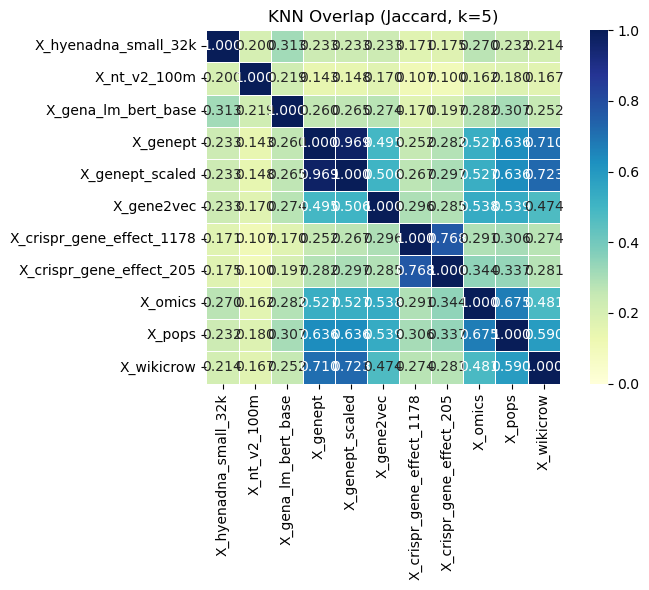

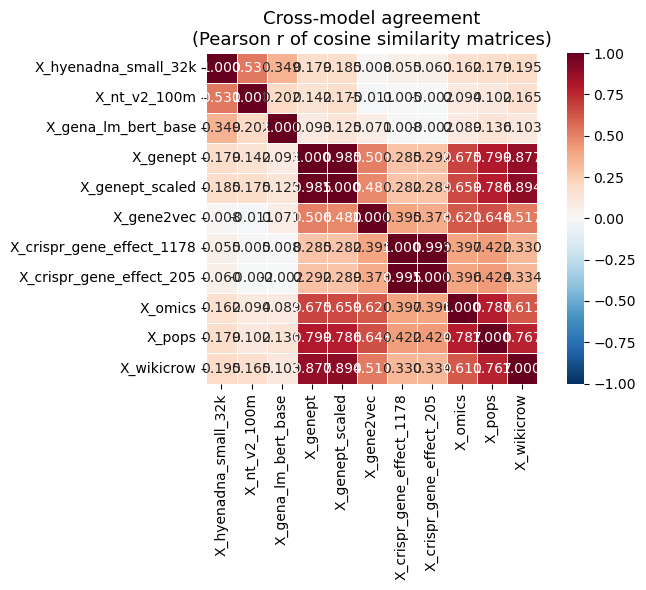

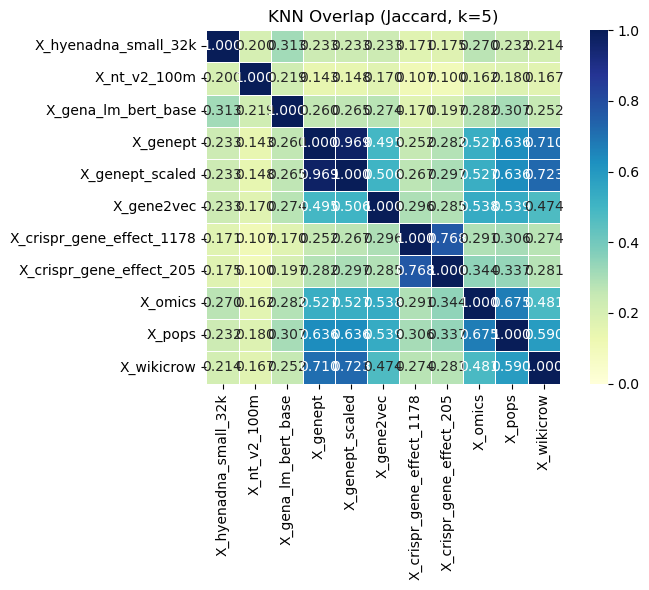

In [25]:
pl.cross_model_similarity(dense_space, obsm_keys=obsm_keys)
pl.knn_overlap(dense_space, obsm_keys=obsm_keys, k=k)

Scale is worth seeing before you ever concatenate, average, or feed these spaces
to a distance-based method. A mean-pooled DNA embedding and a text-derived lookup
table come out of unrelated procedures and have no reason to land at the same
magnitude; the plot below is where you find out whether they do. Wherever they do
not, a naive concatenation is silently a weighted one -- the larger-norm block
dominates every Euclidean distance downstream. Standardise per block first, or
use a metric that does not care.

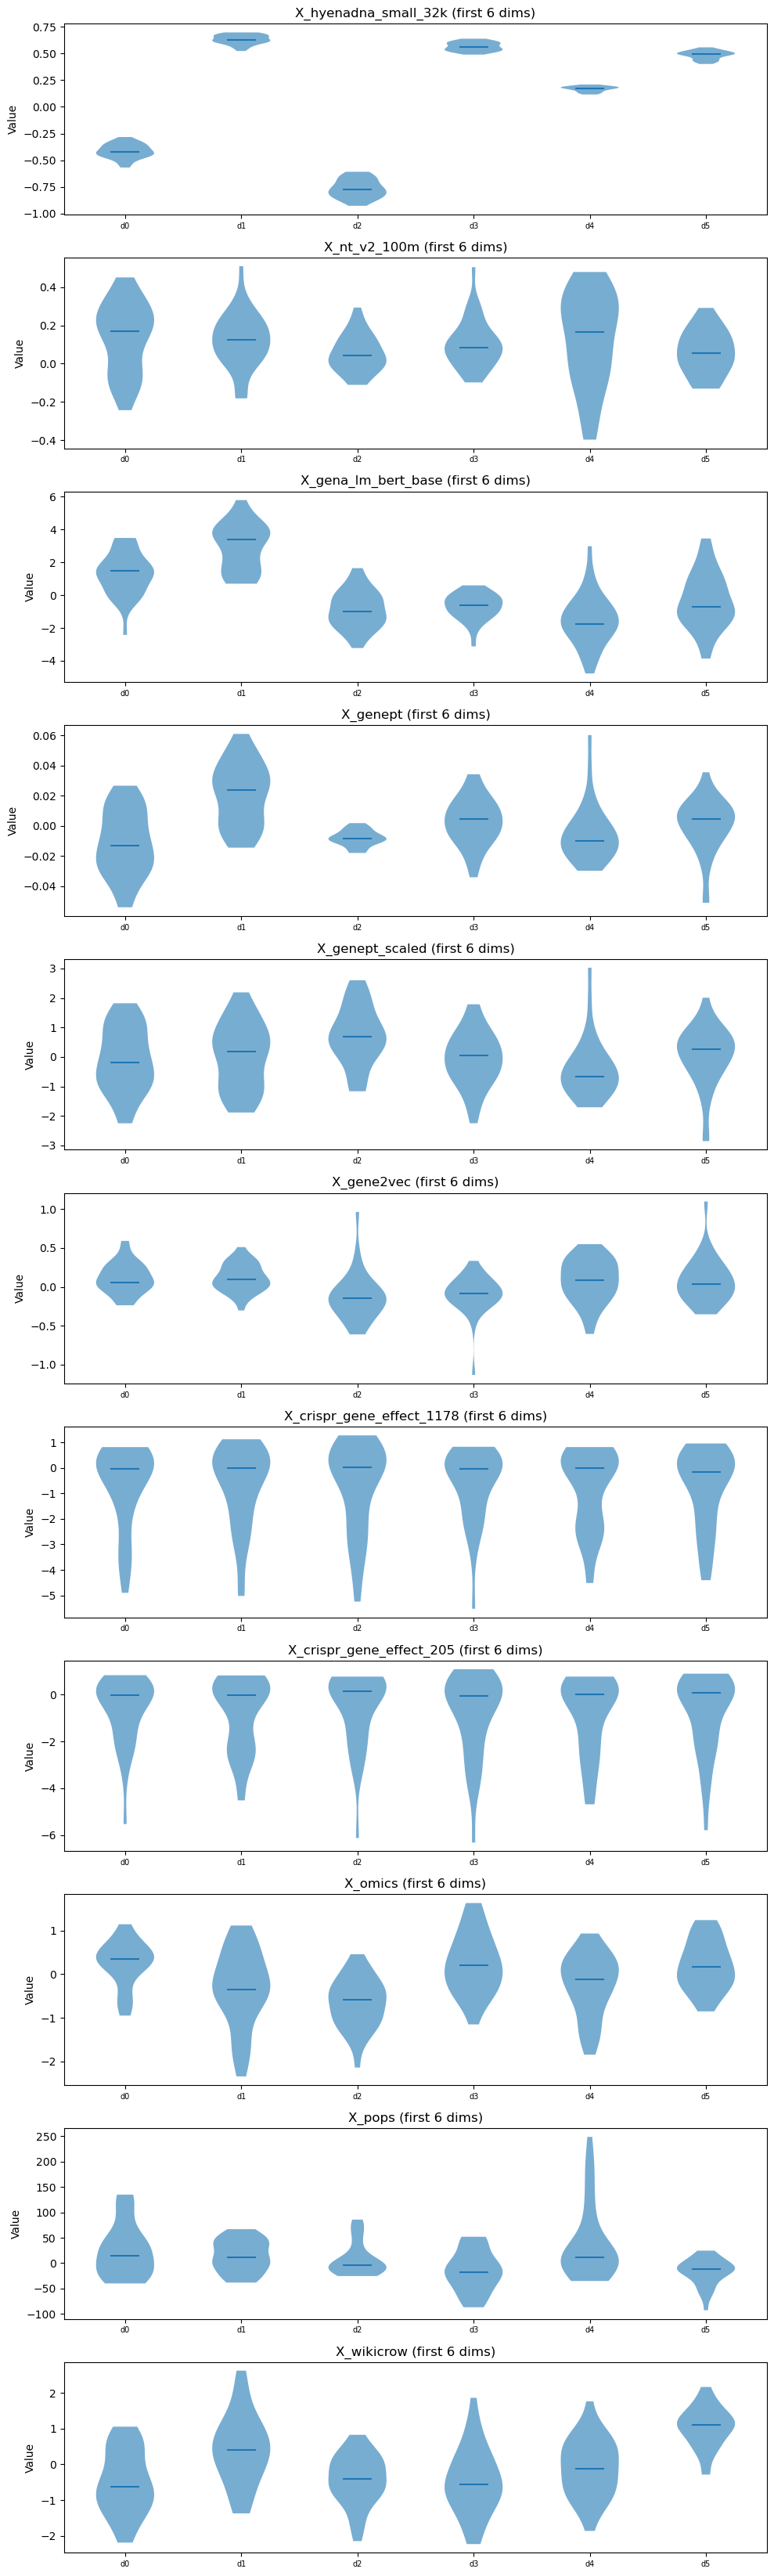

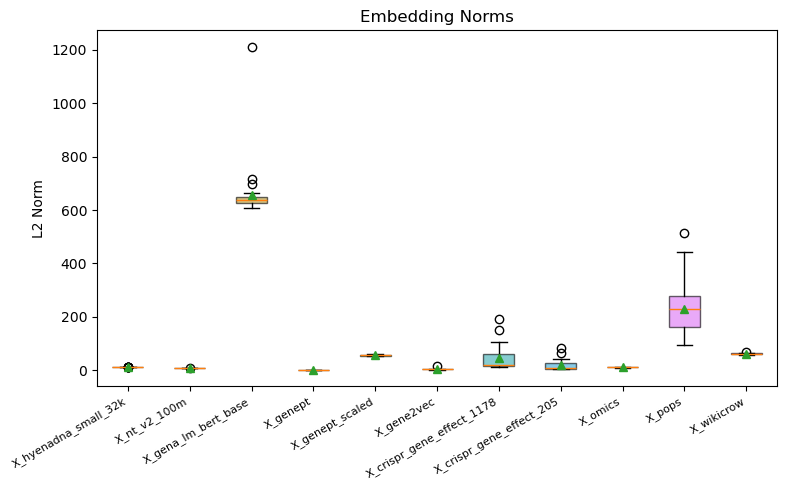

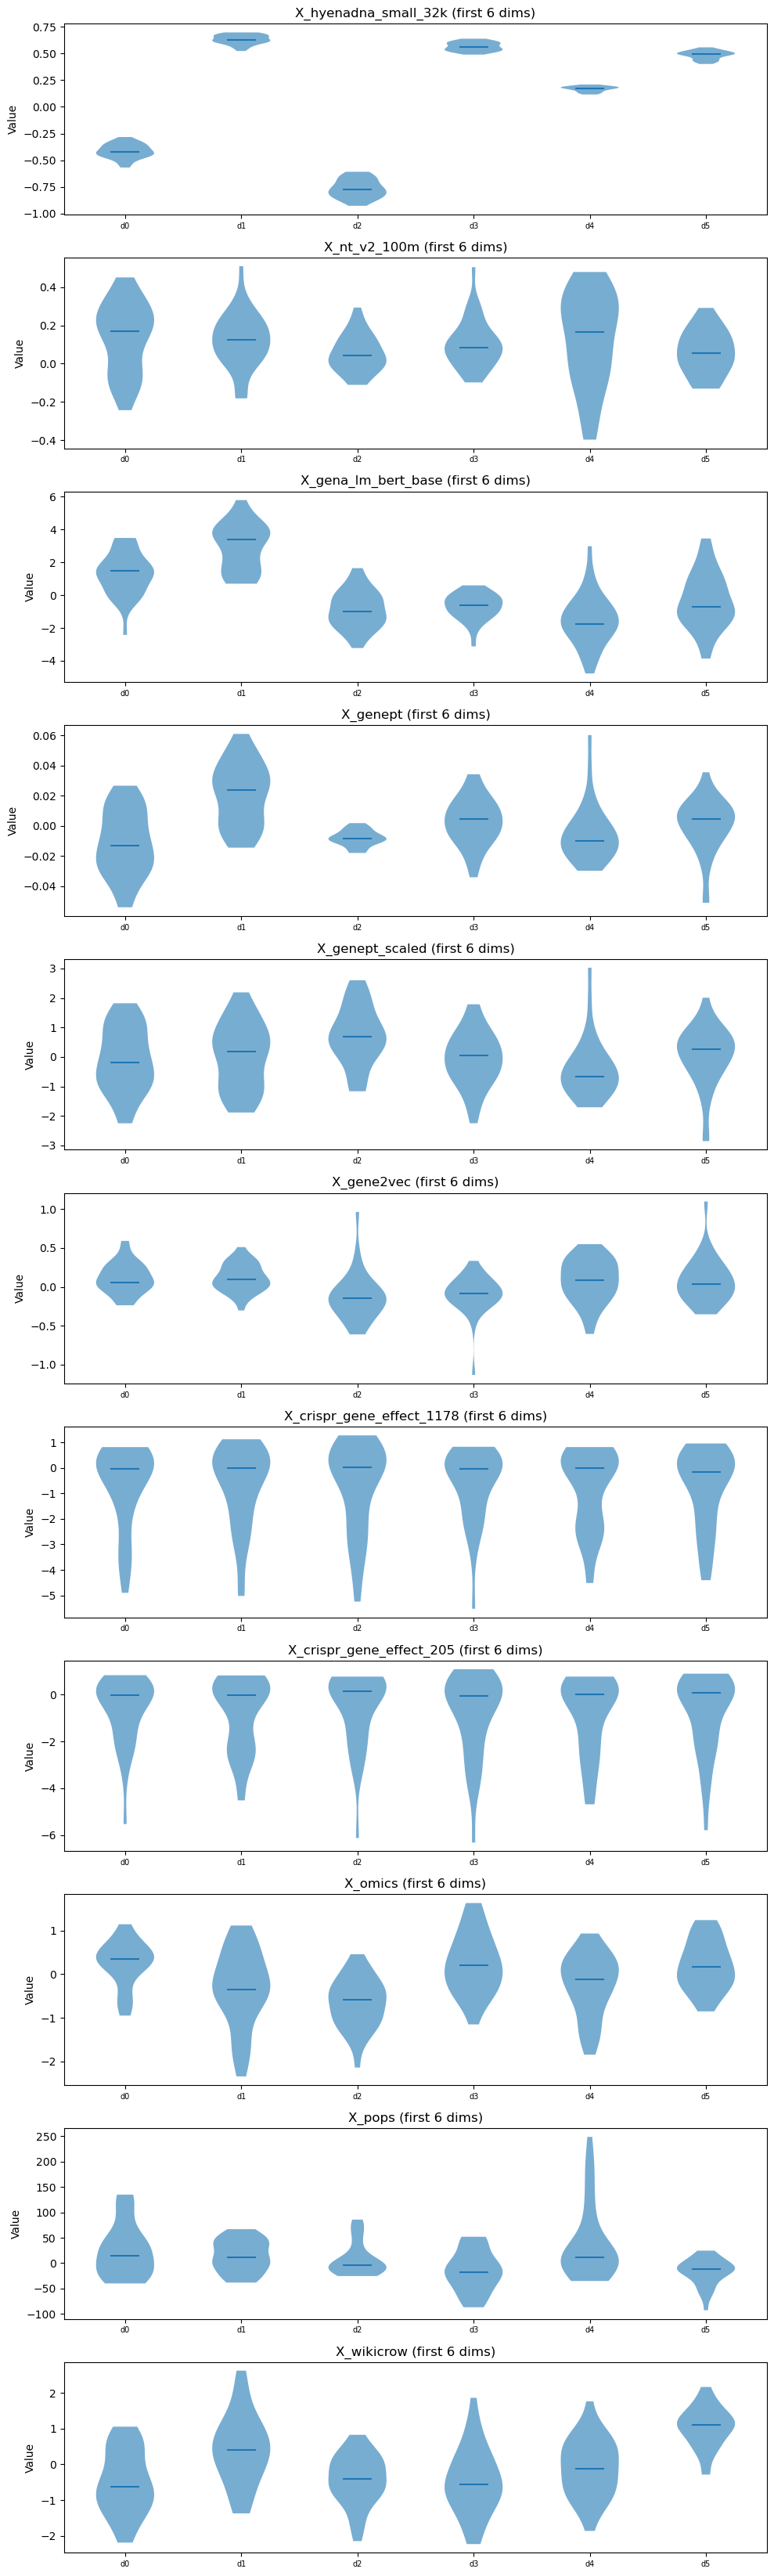

In [26]:
pl.embedding_norms(dense_space, obsm_keys=obsm_keys)
pl.embedding_distributions(dense_space, obsm_keys=obsm_keys, n_dims=6)

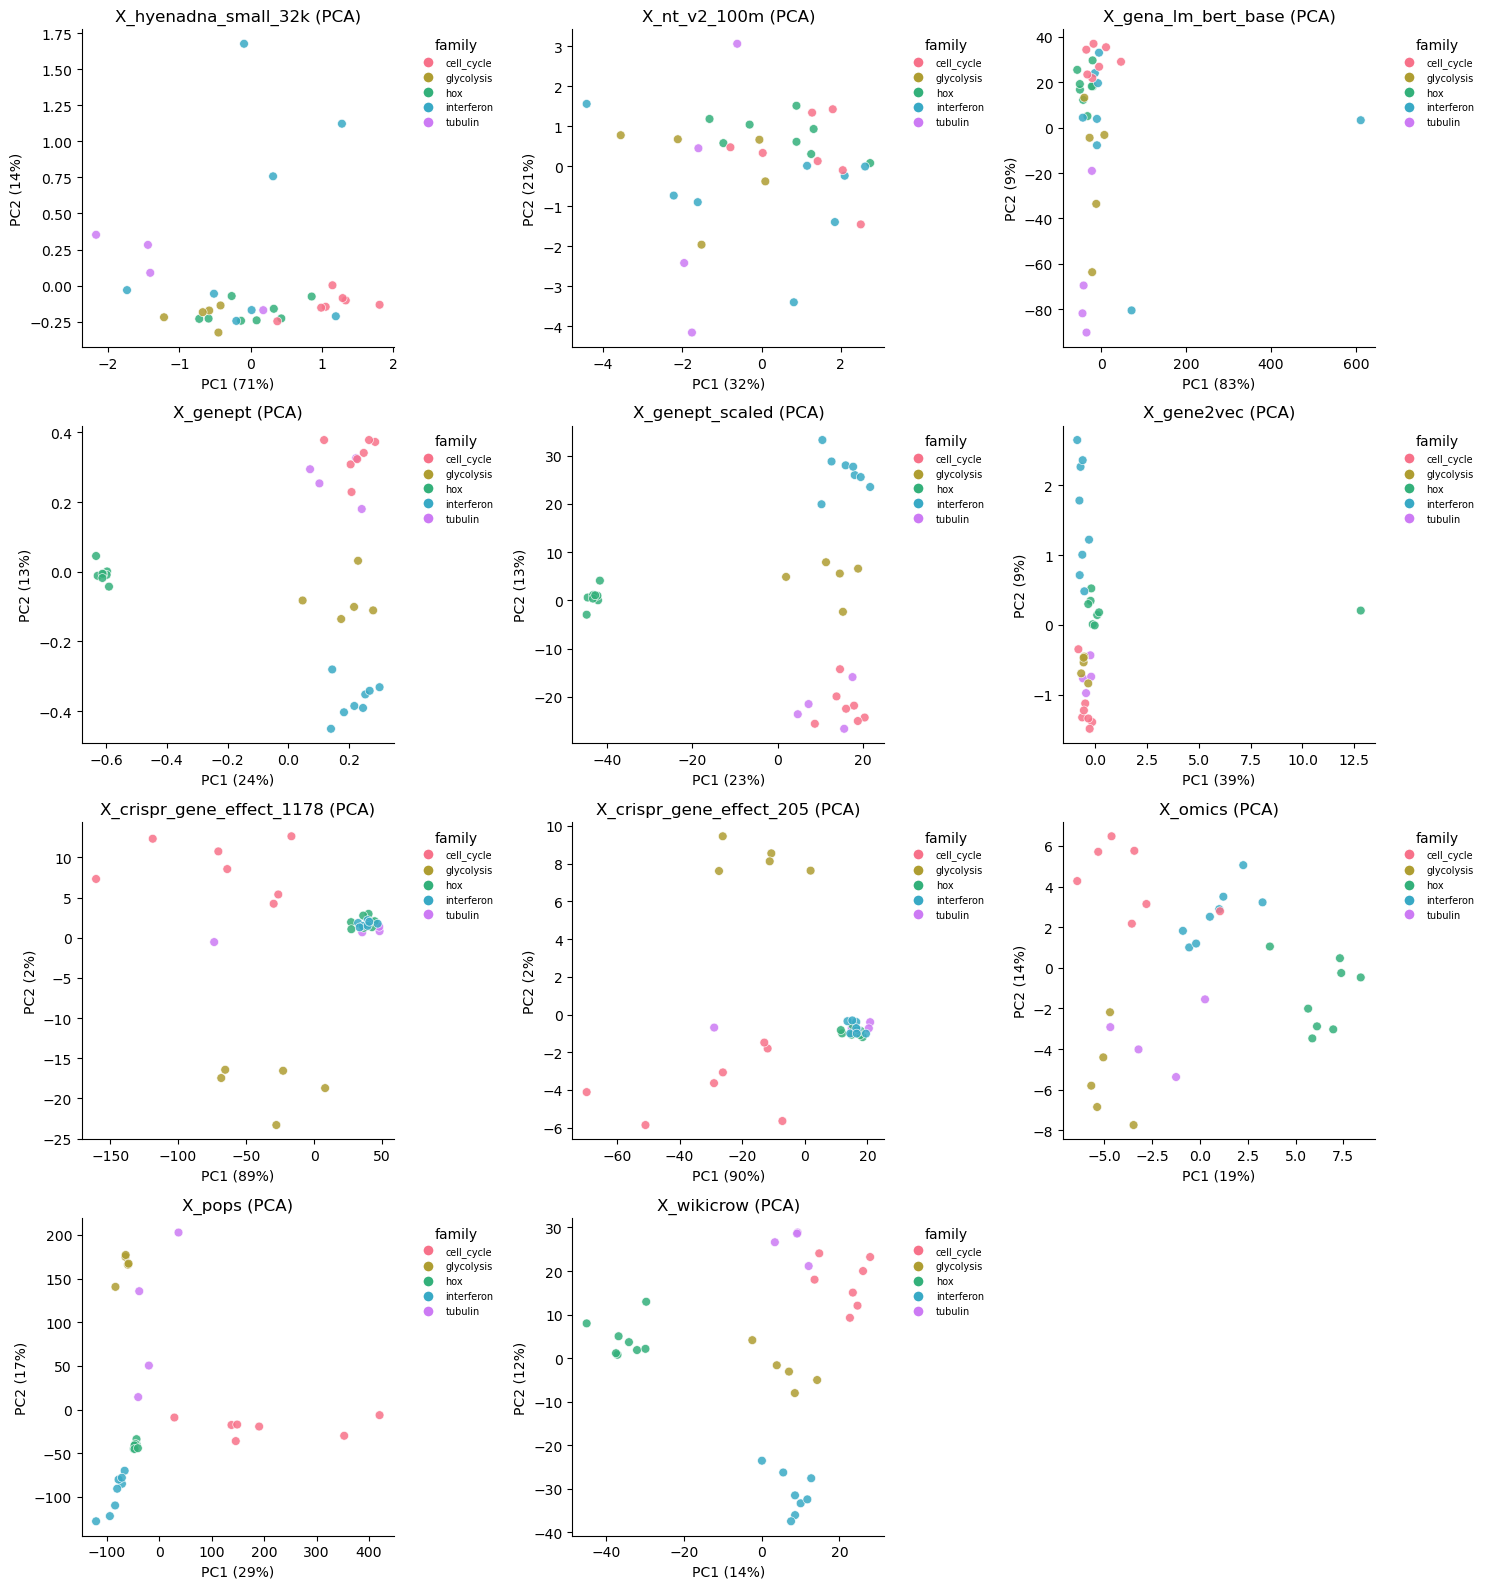

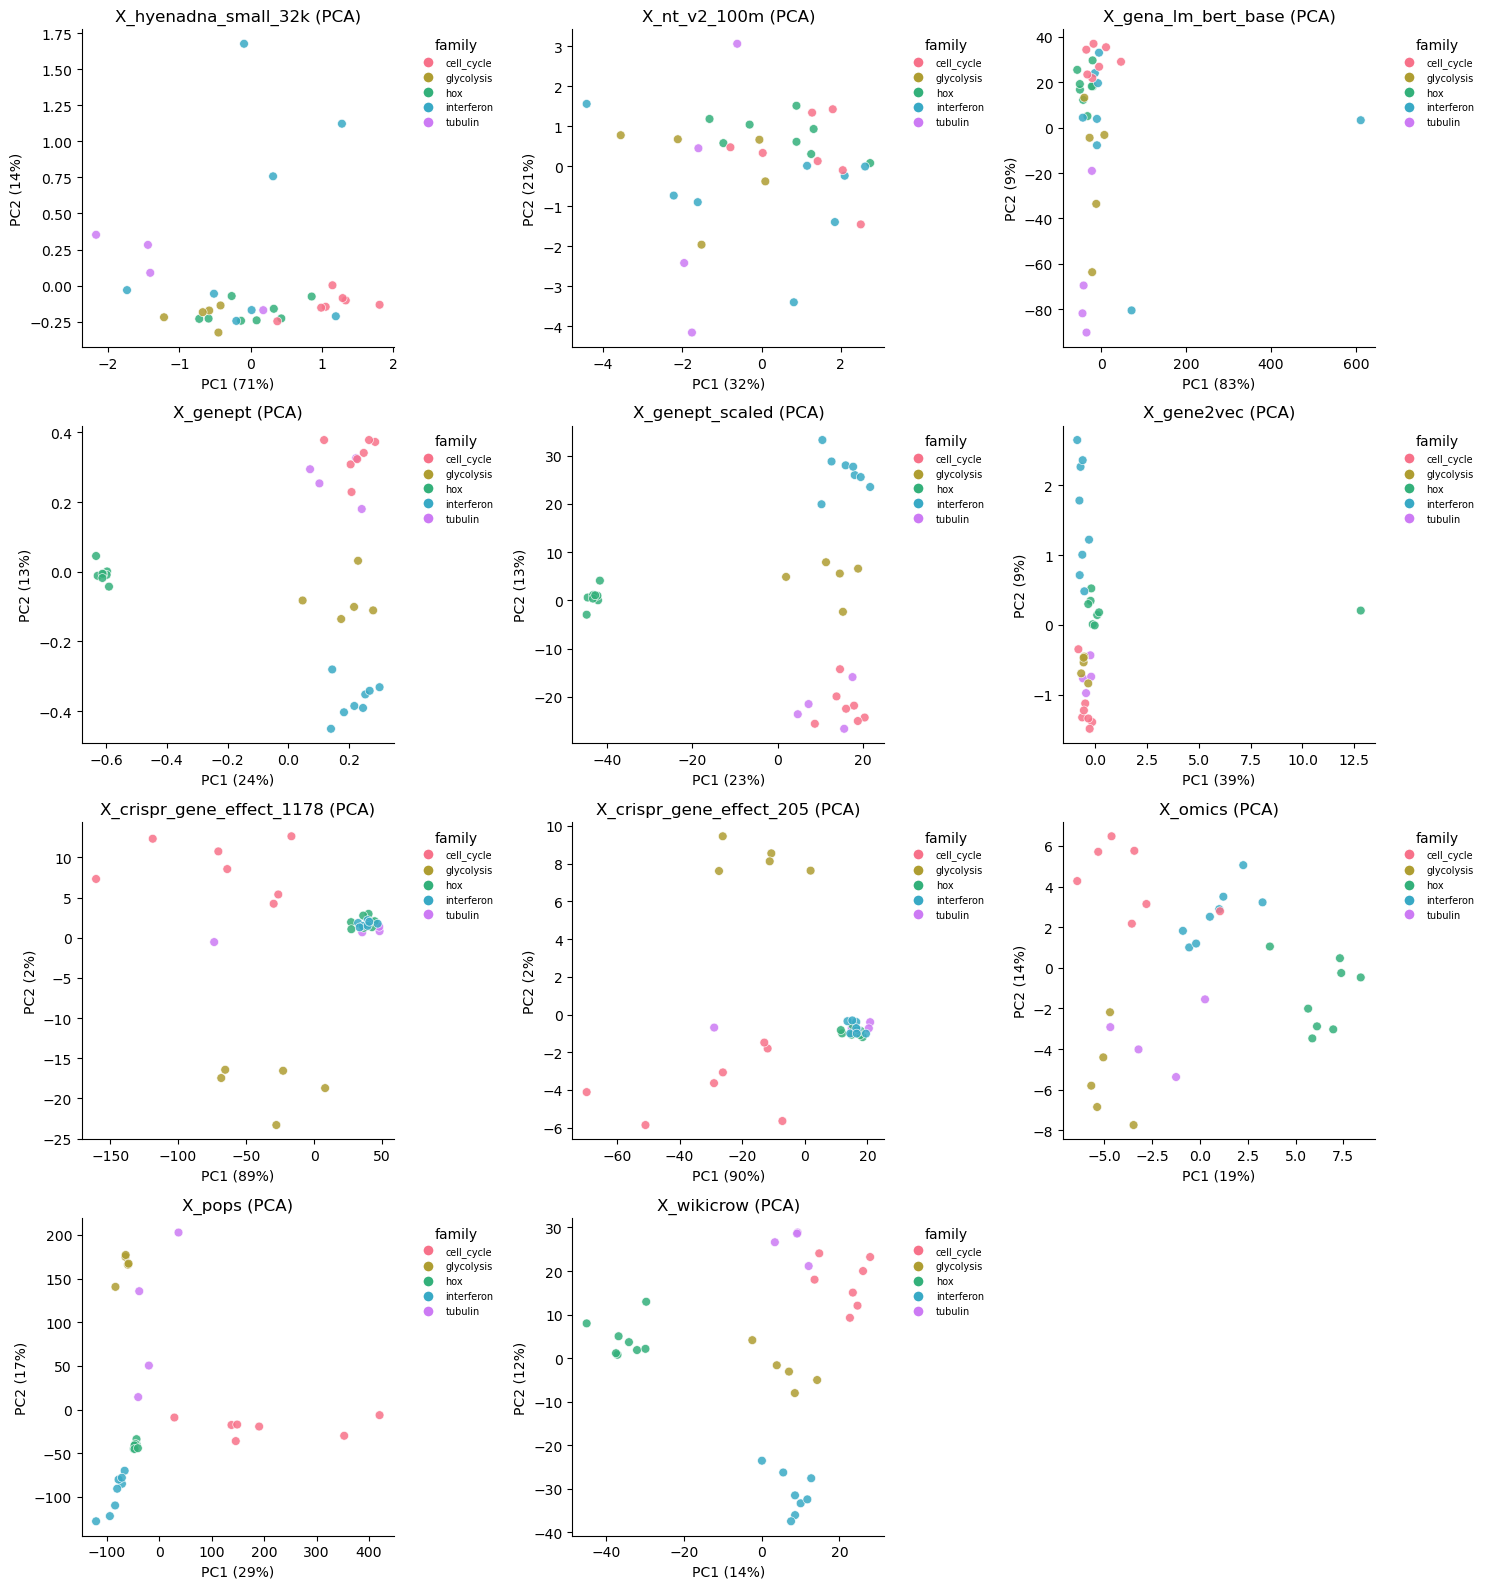

In [27]:
# Same genes, same colouring, one panel per model -- the qualitative counterpart
# to the tables above. PCA rather than UMAP: on a panel this small a UMAP layout
# is mostly an artefact of its own hyperparameters.
pl.all_embeddings(dense_space, obsm_keys=obsm_keys, method="pca",
                  color="family", ncols=3)

## Does the geometry track biology?

Everything so far compared the models *to each other*. Agreement is not
correctness: two models can agree because they are both right, or because they
were both distilled from the same abstracts. The `family` labels are the way out
of that -- no model was ever shown them, no table was queried with them, and no
sequence carries them. They are a fair external test, and this is the section
that scores the prediction the panel was built around.

The prediction has two halves, and they point in opposite directions:

* **DNA models should win on the paralog families.** The classes in
  `SEQUENCE_COHERENT` are duplicates of one ancestral gene, so their members are
  literally similar strings. A model that reads DNA and nothing else has
  everything it needs.
* **DNA models should lose on `glycolysis`, `interferon` and `cell_cycle`.**
  Those members share a pathway and nothing else -- different folds, different
  chromosomes, no sequence relationship to find. The knowledge tables, distilled
  from text, co-expression and screens, are organised by exactly that kind of
  functional co-membership, so they should show the mirror-image pattern.

Both halves are predictions, not results. The cells below compute the two
numbers and choose the verdict sentence from the measured values -- including
the sentence for the case where the prediction is wrong.

Two readouts, deliberately different in scope:

* `pl.within_vs_between_similarity` -- are same-class pairs more similar than
  cross-class pairs? Returns both means, the pair counts, and a Mann-Whitney
  **p-value**.
* `pl.knn_label_purity` -- of each gene's `k` nearest neighbours, how many share
  its class? Returns per-class values plus `__overall__` and `__baseline__`, so
  the number is interpretable rather than merely large.

In [28]:
import matplotlib.pyplot as plt

# Score only what actually produced vectors: a backend that refused to load and a
# table that is advertised but absent from the data repo both simply drop out.
DNA_SCORED = [key for key in DNA_KEYS if spaces.get(key) in dense_space.obsm]
STATIC_SCORED = [key for key in STATIC_KEYS if spaces.get(key) in dense_space.obsm]
SCORED = DNA_SCORED + STATIC_SCORED

# Purity has a ceiling set by class size, not by the model. knn_label_purity asks
# for k+1 neighbours and discards the query itself, so a gene in a class of m
# members has only m-1 class-mates left to find and the best attainable value is
# min(k, m-1)/k. Any gene dropped by the dense mask shrinks its own class and no
# other, so the ceiling is worth computing before reading a single purity number.
class_sizes = dense_space.obs["family"].astype(str).value_counts().sort_index()
K_NN = int(min(5, max(2, class_sizes.min() - 1)))
ceiling = (np.minimum(K_NN, class_sizes - 1).clip(lower=0) / K_NN).rename("max_purity")

print(f"models scored : {len(SCORED)}  ({len(DNA_SCORED)} DNA, {len(STATIC_SCORED)} static)")
print(f"panel         : {dense_space.n_obs} genes, k = {K_NN}\n")
print(pd.concat([class_sizes.rename("genes"), ceiling.round(2)], axis=1).to_string())

models scored : 11  (3 DNA, 8 static)
panel         : 32 genes, k = 3

            genes  max_purity
family                       
cell_cycle      7         1.0
glycolysis      5         1.0
hox             8         1.0
interferon      8         1.0
tubulin         4         1.0


In [29]:
# Both helpers draw as well as return. Sending the per-model figures to one
# throwaway axis pair keeps the ranking table from being buried under 2N plots;
# the models that win get their own plots further down.
scratch = plt.figure(figsize=(9, 3.5))
ax_wb, ax_purity = scratch.add_subplot(121), scratch.add_subplot(122)

scores: list[dict] = []
purities: dict[str, dict] = {}

for key in SCORED:
    obsm = spaces[key]
    X = np.asarray(dense_space.obsm[obsm], dtype=float)
    if not np.isfinite(X).all():
        n_bad = int((~np.isfinite(X)).any(axis=1).sum())
        print(f"skipped {key}: {n_bad} gene(s) still carry NaN, which would poison every mean")
        continue
    try:
        wb = pl.within_vs_between_similarity(dense_space, label_key="family",
                                             obsm_key=obsm, ax=ax_wb)
        purity = pl.knn_label_purity(dense_space, label_key="family",
                                     obsm_key=obsm, k=K_NN, ax=ax_purity)
    except Exception as exc:
        print(f"skipped {key} -- {type(exc).__name__}: {str(exc)[:90]}")
        continue
    purities[key] = purity
    scores.append({
        "model": key,
        "kind": "DNA" if key in DNA_SCORED else "table",
        "within": wb["mean_within"],
        "between": wb["mean_between"],
        "separation": wb["mean_within"] - wb["mean_between"],
        "p_value": wb["p_value"],
        "knn_purity": purity["__overall__"],
        "purity_baseline": purity["__baseline__"],
    })

plt.close(scratch)

# Named columns so an empty sweep still produces a table rather than a KeyError.
ranking = pd.DataFrame(scores, columns=["model", "kind", "within", "between", "separation",
                                        "p_value", "knn_purity", "purity_baseline"])
ranking = ranking.set_index("model")
if len(ranking):
    ranking = ranking.sort_values("separation", ascending=False)
display(ranking.round(4))

best = ranking.index[0] if len(ranking) else None
best_dna = next((m for m in ranking.index if m in DNA_SCORED), None)
best_static = next((m for m in ranking.index if m in STATIC_SCORED), None)
print(f"\nbest class separation : {best}")
print(f"best DNA model        : {best_dna}")
print(f"best knowledge table  : {best_static}")

,kind,within,between,separation,p_value,knn_purity,purity_baseline
model,,,,,,,
crispr_gene_effect_205,table,0.5573,-0.1456,0.7029,0.0,0.6458,0.2129
crispr_gene_effect_1178,table,0.5095,-0.1386,0.6480,0.0,0.5417,0.2129
pops,table,0.5732,-0.0101,0.5833,0.0,0.9896,0.2129
genept_scaled,table,0.5153,0.0159,0.4994,0.0,1.0000,0.2129
omics,table,0.4658,0.0937,0.3721,0.0,0.8958,0.2129
wikicrow,table,0.3749,0.0199,0.3550,0.0,0.9792,0.2129
genept,table,0.7083,0.3910,0.3173,0.0,1.0000,0.2129
gene2vec,table,0.3588,0.1299,0.2289,0.0,0.8646,0.2129
nt_v2_100m,DNA,0.8885,0.8627,0.0258,0.0,0.3542,0.2129



best class separation : crispr_gene_effect_205
best DNA model        : nt_v2_100m
best knowledge table  : crispr_gene_effect_205


Read `separation` and `knn_purity` together; they can disagree, and the
disagreement is informative.

**Separation is global.** It averages over every same-class pair and every
cross-class pair at once, so one class parked far away from the rest can carry
the whole number while the remaining classes sit on top of each other.
**Purity is local.** It only ever looks at a gene's `k` nearest neighbours, so it
answers the question you actually act on: if I hand this space a gene and ask for
"genes like this one", do I get its class-mates back? If you are going to cluster
the space, separation is the number to care about; if you are going to query it,
purity is.

The p-value is the least interesting column. With this many pairs the
Mann-Whitney test detects almost any real difference, so a tiny p tells you the
split is not noise -- it says nothing about whether the split is *large*. The two
means and their difference carry that.

### Where each model works, class by class

The overall purity hides the thing the panel was designed to expose. Broken out
per class, and with the attainable ceiling printed next to it, the table below is
the actual test: the `SEQUENCE_COHERENT` rows come first, the pathway rows after,
and the columns are in the ranking order from above.

In [30]:
per_class = pd.DataFrame({
    key: {cls: value for cls, value in purities[key].items() if not cls.startswith("__")}
    for key in ranking.index
})

order = ([c for c in class_sizes.index if c in SEQUENCE_COHERENT]
         + [c for c in class_sizes.index if c not in SEQUENCE_COHERENT])
per_class = per_class.reindex(order)

coherence = pd.Series(
    {c: "sequence" if c in SEQUENCE_COHERENT else "function" for c in order},
    name="coherence",
)
display(pd.concat([coherence, ceiling.reindex(order).round(2), per_class.round(3)], axis=1))

,coherence,max_purity,crispr_gene_effect_205,crispr_gene_effect_1178,pops,genept_scaled,omics,wikicrow,genept,gene2vec,nt_v2_100m,hyenadna_small_32k,gena_lm_bert_base
hox,sequence,1.0,0.625,0.375,1.000,1.0,1.000,1.000,1.0,0.958,0.625,0.667,0.708
tubulin,sequence,1.0,0.333,0.250,0.917,1.0,0.583,1.000,1.0,0.667,0.083,0.417,0.500
cell_cycle,function,1.0,1.000,0.952,1.000,1.0,0.905,0.952,1.0,1.000,0.333,0.524,0.714
glycolysis,function,1.0,0.800,0.667,1.000,1.0,0.933,0.933,1.0,0.533,0.267,0.600,0.200
interferon,function,1.0,0.417,0.417,1.000,1.0,0.917,1.000,1.0,0.958,0.292,0.208,0.250


In [31]:
SEQ_CLASSES = [c for c in per_class.index if c in SEQUENCE_COHERENT]
FUN_CLASSES = [c for c in per_class.index if c not in SEQUENCE_COHERENT]


# Mean purity over one block of the table; NaN when the block is empty, so a
# missing model family shows up as NaN instead of a confident-looking zero.
def group_mean(models: list[str], classes: list[str]) -> float:
    cols = [m for m in models if m in per_class.columns]
    if not cols or not classes:
        return float("nan")
    block = per_class.loc[classes, cols].to_numpy(dtype=float)
    return float(np.nanmean(block)) if np.isfinite(block).any() else float("nan")


# family_summary, not summary: section 1 already bound `summary` to the pairwise
# metric table and this notebook runs in one kernel.
family_summary = pd.DataFrame(
    [
        {"paralog families": group_mean(DNA_SCORED, SEQ_CLASSES),
         "pathway classes": group_mean(DNA_SCORED, FUN_CLASSES)},
        {"paralog families": group_mean(STATIC_SCORED, SEQ_CLASSES),
         "pathway classes": group_mean(STATIC_SCORED, FUN_CLASSES)},
    ],
    index=["DNA sequence models", "knowledge tables"],
)
family_summary["advantage"] = (family_summary["paralog families"]
                               - family_summary["pathway classes"])
display(family_summary.round(3))

baseline = purities[ranking.index[0]]["__baseline__"] if len(ranking) else float("nan")
print(f"random baseline (from the class sizes): {baseline:.3f}"
      f"   -- a balanced panel would give 1/{len(PANEL)} = {1 / len(PANEL):.3f}")

seq_ceiling = float(ceiling.reindex(SEQ_CLASSES).mean()) if SEQ_CLASSES else float("nan")
fun_ceiling = float(ceiling.reindex(FUN_CLASSES).mean()) if FUN_CLASSES else float("nan")
if abs(seq_ceiling - fun_ceiling) > 0.02:
    print(f"caution: the two groups do not have the same ceiling "
          f"({seq_ceiling:.2f} vs {fun_ceiling:.2f}), so part of any advantage below "
          "is class size rather than biology.")

,paralog families,pathway classes,advantage
DNA sequence models,0.500,0.376,0.124
knowledge tables,0.794,0.891,-0.097


random baseline (from the class sizes): 0.213   -- a balanced panel would give 1/5 = 0.200


In [32]:
dna_adv = float(family_summary.loc["DNA sequence models", "advantage"])
tbl_adv = float(family_summary.loc["knowledge tables", "advantage"])

# The verdict is picked by the measured numbers, not written in advance. Positive
# advantage = that family scores higher on the paralog families than on the
# pathway classes; the prediction is that the two signs are opposite.
if not np.isfinite(dna_adv) or not np.isfinite(tbl_adv):
    PREDICTION_VERDICT = (
        "NOT SCORED: one of the two model families produced no usable space on this "
        "panel, so there is nothing to compare. Re-run the embedding section and "
        "check the skip reasons printed there."
    )
elif dna_adv > 0 > tbl_adv:
    PREDICTION_VERDICT = (
        f"CONFIRMED: on the paralog families the DNA models gain {dna_adv:.3f} purity "
        f"over their own score on the pathway classes, while the knowledge tables lose "
        f"{abs(tbl_adv):.3f} -- opposite signs, which is the prediction. Each family is "
        "better at the classes its own evidence can see; the per-class table above says "
        "how far above the baseline each one still sits on its weak side."
    )
elif dna_adv > tbl_adv:
    leaning = ("both lean towards the paralog families" if dna_adv > 0 and tbl_adv > 0
               else "both lean towards the pathway classes" if dna_adv < 0 and tbl_adv < 0
               else "one of the two is flat")
    PREDICTION_VERDICT = (
        f"PARTLY CONFIRMED: the ordering holds -- the DNA models carry the larger "
        f"sequence-class advantage ({dna_adv:+.3f} against the tables' {tbl_adv:+.3f}) "
        f"-- but the two signs do not oppose each other: {leaning}, so only the size "
        "of the gap separates the two kinds of model. Read the two signs in the "
        "table above before reading the gap."
    )
elif tbl_adv > dna_adv:
    PREDICTION_VERDICT = (
        f"REFUTED: the knowledge tables carry the larger sequence-class advantage "
        f"({tbl_adv:+.3f} against the DNA models' {dna_adv:+.3f}), the opposite way "
        "round from the prediction. One explanation this notebook cannot rule out is "
        "that paralogs are not only sequence neighbours: they are co-expressed, "
        "co-cited and screened together, so a table has its own route to them. "
        "Testing that would mean scoring a table against a paralog set the "
        "literature has not written about, which is not something this panel does."
    )
else:
    PREDICTION_VERDICT = (
        f"INCONCLUSIVE: the two advantages are equal ({dna_adv:+.3f}), so on this "
        "panel the sequence / function split does not separate the two kinds of "
        "model at all. With this few models and this few genes per class an exact "
        "tie is more likely a sign that the purity numbers have saturated -- check "
        "them against the ceiling column above before reading anything into it."
    )

PREDICTION_DELTAS = {"dna_advantage": dna_adv, "table_advantage": tbl_adv,
                     "purity_baseline": baseline, "k": K_NN,
                     "n_dna_models": len([m for m in DNA_SCORED if m in per_class.columns]),
                     "n_table_models": len([m for m in STATIC_SCORED if m in per_class.columns])}
print(PREDICTION_VERDICT)

CONFIRMED: on the paralog families the DNA models gain 0.124 purity over their own score on the pathway classes, while the knowledge tables lose 0.097 -- opposite signs, which is the prediction. Each family is better at the classes its own evidence can see; the per-class table above says how far above the baseline each one still sits on its weak side.


Whatever the printed verdict, two things about the *shape* of the table are worth
keeping.

The paralog families are the easy case for a sequence model, and for a boring
reason: their members descend from one duplicated ancestral gene, so their coding
sequences are related by descent and "similar embedding" needs no biology at all
-- string similarity is enough. That is a genuine capability and also a low bar.
This notebook never measures percent identity, so treat the mechanism as the
panel's design assumption; what it does measure is the consequence, in the
`hits` column of the TUBB4B probe in the previous section and in the paralog
rows above.

The pathway classes are the hard case for the same boring reason in reverse.
`GAPDH` and `ENO1` catalyse different steps of one route and belong to unrelated
protein families; they are neighbours in a metabolic chart and nowhere else. A
model that recovered them from exon sequence alone would have to have learned
something shared across unrelated loci -- regulatory grammar, codon usage,
GC context -- and distinguishing that from a confound is well beyond what a
40-gene panel can do.

The one place to be careful is the assumption that the tables are *blind* to
paralogy. They are not: tubulin genes co-express, get cited in the same papers,
and drop out together in CRISPR screens, so a co-expression or text-derived table
has its own route to the same answer. That is why the verdict above is stated as
a contrast between two advantages rather than as a DNA-models-only claim.
`PREDICTION_VERDICT` and `PREDICTION_DELTAS` keep the sentence and its numbers in
the kernel, so anything later in the session can quote the measured result
instead of restating it from memory.

### Which classes does each family of model confuse?

Centroid similarity answers that directly: each class is reduced to its mean
vector and the heatmap is the cosine between them. The diagonal is 1 by
construction, so only the **off-diagonal** matters -- heat there is a pair the
model cannot tell apart. Best DNA model and best table, side by side, on the same
colour scale.

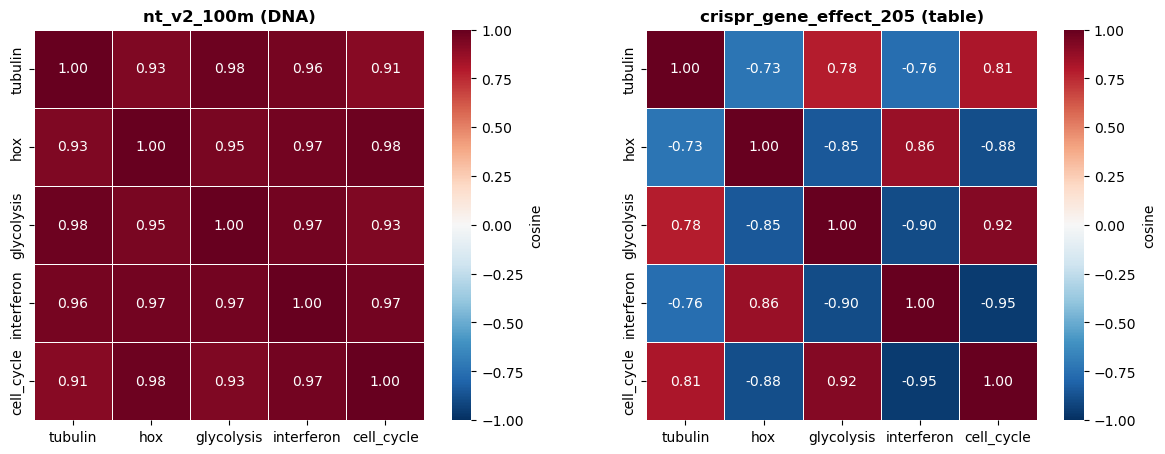

In [33]:
candidates = ((best_dna, "DNA"), (best_static, "table"))
centroid_panels = [(model, kind) for model, kind in candidates if model is not None]
absent = [kind for model, kind in candidates if model is None]

if not centroid_panels:
    print("neither family produced a usable space, so there is nothing to draw.")
else:
    if absent:
        print(f"no {' or '.join(absent)} model was scored -- only the "
              f"{centroid_panels[0][1]} side is drawn, so this is not a contrast.")
    # category_centroid_similarity fixes vmin/vmax at -1/1, so the two panels are
    # on one colour scale without being told to be.
    fig, axes = plt.subplots(1, len(centroid_panels),
                             figsize=(6.2 * len(centroid_panels), 4.6))
    for ax, (model, kind) in zip(np.atleast_1d(axes), centroid_panels):
        pl.category_centroid_similarity(dense_space, label_key="family",
                                        obsm_key=spaces[model], ax=ax,
                                        title=f"{model} ({kind})")
    fig.tight_layout()

## Unsupervised structure

Purity and separation both use the labels. Clustering asks the same question
without them: left to itself, does the winning space rediscover the panel?
`cluster_annotation_enrichment` then scores each cluster against `family`, so a
cluster that is one class and nothing else shows up as a high fold-enrichment
row.

Leiden goes through scanpy and needs `leidenalg` and `igraph`; if they are
missing the cell says so and the notebook carries on.

In [34]:
if best is None:
    print("no scored model, so clustering is skipped.")
else:
    try:
        dense_space = tl.cluster_embeddings(
            dense_space, obsm_key=spaces[best], method="leiden",
            resolution=1.0, n_neighbors=8, key_added="cluster",
        )
        print(f"leiden on {best}:")
        print(dense_space.obs["cluster"].value_counts().sort_index().to_string())
        print(f"\n{dense_space.obs['cluster'].nunique()} clusters for "
              f"{len(class_sizes)} true classes\n")
        display(tl.cluster_annotation_enrichment(dense_space, cluster_key="cluster",
                                                 annotation_key="family", top_k=3))
    except ImportError as exc:
        print(f"leiden unavailable -- {exc}\n  pip install leidenalg igraph")
    except Exception as exc:
        print(f"clustering skipped -- {type(exc).__name__}: {str(exc)[:120]}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


/Users/grpinto/Documents/embpy/src/embpy/tl/clustering.py:128: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added=key_added)


leiden on crispr_gene_effect_205:
cluster
0    13
1     7
2     6
3     6

4 clusters for 5 true classes



,cluster,term,in_cluster,overall,in_freq,overall_freq,enrichment
0,0,interferon,7,8,0.538,0.250,2.15
1,0,hox,5,8,0.385,0.250,1.54
2,0,tubulin,1,4,0.077,0.125,0.62
3,1,cell_cycle,4,7,0.571,0.219,2.61
4,1,glycolysis,2,5,0.286,0.156,1.83
5,1,tubulin,1,4,0.143,0.125,1.14
6,2,tubulin,2,4,0.333,0.125,2.67
7,2,hox,3,8,0.500,0.250,2.00
8,2,interferon,1,8,0.167,0.250,0.67
9,3,glycolysis,3,5,0.500,0.156,3.20


The cluster count is worth reading before the enrichment table. Leiden at
resolution 1.0 is told nothing about how many classes the panel has, so compare
the count it printed against the class count next to it: more clusters than
classes means it split a class -- usually the one whose members are least alike
-- and fewer means it merged two, which is the same confusion the off-diagonal
heat above showed, now expressed as a partition.

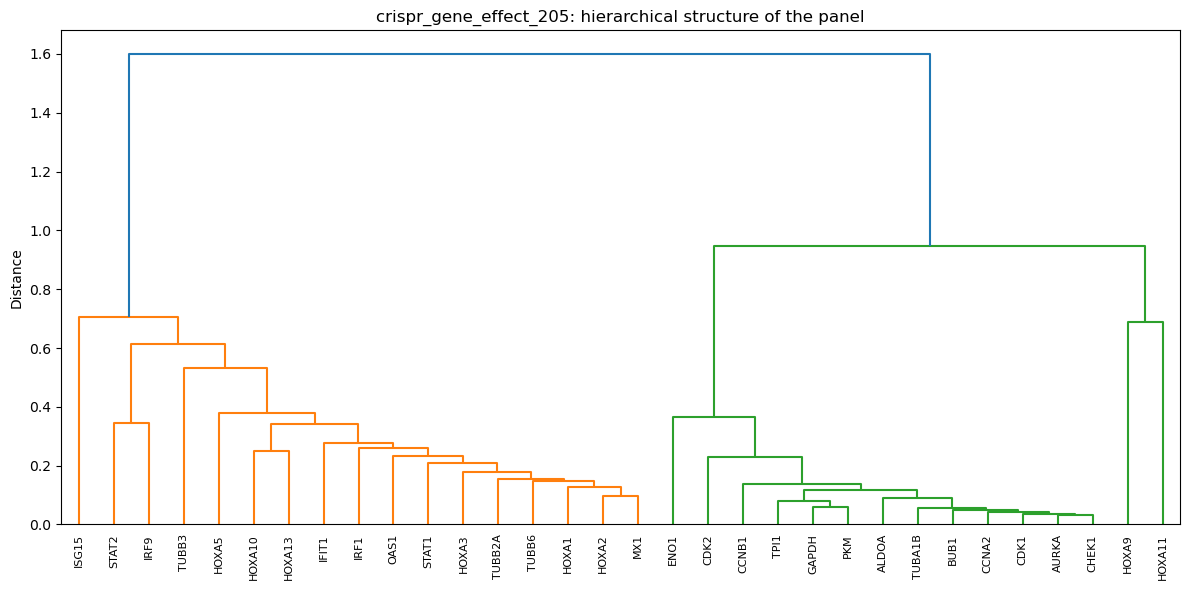

In [35]:
if best is not None:
    pl.dendrogram(dense_space, obsm_key=spaces[best], metric="cosine",
                  title=f"{best}: hierarchical structure of the panel")

## Annotate the genes

`tl.annotate_gene_perturbations` fetches per-gene metadata from MyGene.info
(pathways), STRING and DoRothEA (interactions, regulators) and Open Targets plus
the GWAS Catalog (diseases). Compact counts land in `.obs` as `gene_*`, full
records in `.uns["gene_annotations"]`.

Three practical notes:

* It is one network round-trip per gene per source, so it is slow and it can
  fail. The call is wrapped, and a failure leaves the rest of the notebook
  intact.
* The five `gene_*` columns are written **whatever** you pass as `sources` --
  only the ones whose source was queried carry content. `expression` is not
  requested here, so `gene_top_tissue` should come back empty; the cell after
  measures which columns are actually populated rather than assuming.
* These are real measured properties that no embedding was trained on, which
  makes them usable twice: as colouring here, and as *prediction targets* in the
  next section.

In [36]:
annotated = False
annot_t0 = time.perf_counter()
try:
    dense_space = tl.annotate_gene_perturbations(
        dense_space, column="symbol",
        sources=["pathways", "interactions", "diseases"], copy=True,
    )
    annotated = True
except Exception as exc:
    print(f"annotation skipped -- {type(exc).__name__}: {str(exc)[:140]}")
annot_seconds = time.perf_counter() - annot_t0

records = dense_space.uns.get("gene_annotations", {}) if annotated else {}
gene_cols = [c for c in dense_space.obs.columns if c.startswith("gene_")] if annotated else []
if records:
    print(f"{len(records)} full records in .uns['gene_annotations'], fetched in "
          f"{annot_seconds:.1f}s ({annot_seconds / len(records):.2f}s per gene)")
else:
    print(f"no records in .uns['gene_annotations'] after {annot_seconds:.1f}s")
print(f"gene_* columns written: {gene_cols}\n")

for col in gene_cols:
    values = dense_space.obs[col]
    if pd.api.types.is_numeric_dtype(values):
        filled = int((values > 0).sum())
        print(f"{col:<32} {filled:>3}/{len(values)} non-zero   max {values.max()}")
    else:
        # "" is what the annotator writes for a source it never queried; "nan" and
        # "None" only appear if something upstream wrote a null, and neither counts
        # as content.
        text = values.astype(str).str.strip()
        filled = int((~text.isin(["", "nan", "None", "<NA>"])).sum())
        print(f"{col:<32} {filled:>3}/{len(values)} non-empty")

32 full records in .uns['gene_annotations'], fetched in 143.4s (4.48s per gene)
gene_* columns written: ['gene_symbol', 'gene_n_pathways', 'gene_n_ppi_partners', 'gene_n_disease_assoc', 'gene_n_transcription_factors', 'gene_top_tissue', 'gene_n_ppi_partners_at_limit', 'gene_n_disease_assoc_at_limit']

gene_symbol                       32/32 non-empty
gene_n_pathways                   30/32 non-zero   max 76
gene_n_ppi_partners               32/32 non-zero   max 10
gene_n_disease_assoc              31/32 non-zero   max 20
gene_n_transcription_factors       0/32 non-zero   max 0
gene_top_tissue                    0/32 non-empty
gene_n_ppi_partners_at_limit      32/32 non-zero   max True
gene_n_disease_assoc_at_limit     31/32 non-zero   max True


In [37]:
if gene_cols:
    display(dense_space.obs[["family", *gene_cols]].head(10))
    numeric_cols = [c for c in gene_cols if pd.api.types.is_numeric_dtype(dense_space.obs[c])]
    if numeric_cols:
        by_family = dense_space.obs.groupby("family", observed=True)[numeric_cols].mean()
        display(by_family.round(1))
        # Say which class is richest and which is sparsest rather than leaving it to
        # the reader's eye -- the point of the table is the spread, not the values.
        for col in numeric_cols:
            column = by_family[col].dropna()
            if column.empty or column.max() <= 0:
                print(f"{col:<32} all zero -- the lookup returned nothing for any class")
                continue
            print(f"{col:<32} richest {column.idxmax()} ({column.max():.1f})   "
                  f"sparsest {column.idxmin()} ({column.min():.1f})")

,family,gene_symbol,gene_n_pathways,gene_n_ppi_partners,gene_n_disease_assoc,gene_n_transcription_factors,gene_top_tissue,gene_n_ppi_partners_at_limit,gene_n_disease_assoc_at_limit
gene,,,,,,,,,
TUBA1B,tubulin,TUBA1B,15,10,20,0,,True,True
TUBB2A,tubulin,TUBB2A,12,10,20,0,,True,True
TUBB3,tubulin,TUBB3,13,10,20,0,,True,True
TUBB6,tubulin,TUBB6,12,10,20,0,,True,True
HOXA1,hox,HOXA1,3,10,20,0,,True,True
HOXA2,hox,HOXA2,7,10,20,0,,True,True
HOXA3,hox,HOXA3,3,10,20,0,,True,True
HOXA5,hox,HOXA5,0,10,20,0,,True,True
HOXA9,hox,HOXA9,1,10,20,0,,True,True


,gene_n_pathways,gene_n_ppi_partners,gene_n_disease_assoc,gene_n_transcription_factors,gene_n_ppi_partners_at_limit,gene_n_disease_assoc_at_limit
family,,,,,,
cell_cycle,15.4,10.0,20.0,0.0,1.0,1.0
glycolysis,11.6,10.0,20.0,0.0,1.0,1.0
hox,2.2,10.0,20.0,0.0,1.0,1.0
interferon,21.4,10.0,17.5,0.0,1.0,0.9
tubulin,13.0,10.0,20.0,0.0,1.0,1.0


gene_n_pathways                  richest interferon (21.4)   sparsest hox (2.2)
gene_n_ppi_partners              richest cell_cycle (10.0)   sparsest cell_cycle (10.0)
gene_n_disease_assoc             richest cell_cycle (20.0)   sparsest interferon (17.5)
gene_n_transcription_factors     all zero -- the lookup returned nothing for any class
gene_n_ppi_partners_at_limit     richest cell_cycle (1.0)   sparsest cell_cycle (1.0)
gene_n_disease_assoc_at_limit    richest cell_cycle (1.0)   sparsest interferon (0.9)


Those per-class means are a sanity check on the *annotations*, not on any
embedding. Well-studied classes should come out richest, and the printed
richest/sparsest lines are where to check that -- interferon and cell-cycle genes
sit in dense interaction neighbourhoods and are heavily cited, so a run that puts
a paralog family top instead is telling you something about coverage rather than
about the panel. A class that comes back all zero means the lookup failed for
those symbols, not that the biology is sparse.

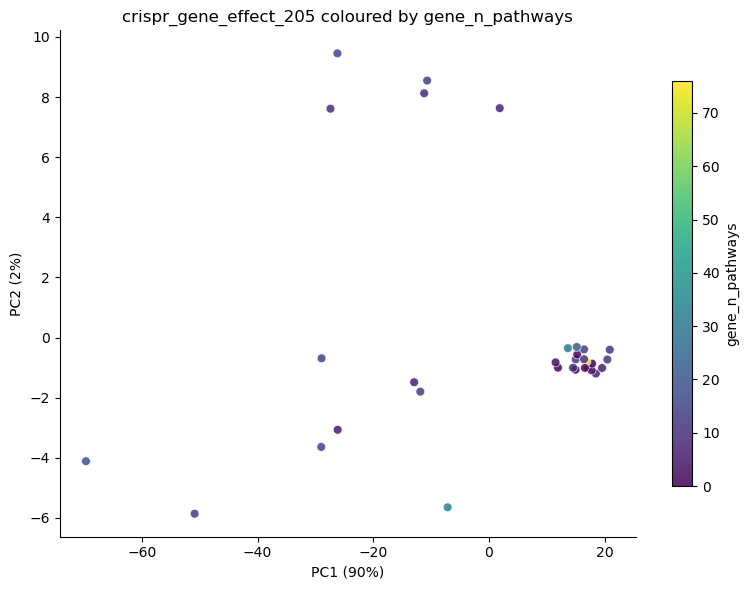

In [38]:
ANNOT_COLOR = next(
    (c for c in ("gene_n_pathways", "gene_n_ppi_partners", "gene_n_disease_assoc")
     if c in dense_space.obs.columns
     and pd.to_numeric(dense_space.obs[c], errors="coerce").fillna(0).max() > 0),
    None,
)

if best is None:
    print("no scored model, so there is nothing to plot.")
elif ANNOT_COLOR is None:
    print("no annotation column landed with a non-zero value, so colouring by one "
          "would draw a single flat colour -- only the label plot below is drawn.")
else:
    pl.plot_embedding_space(dense_space, obsm_key=spaces[best], method="pca",
                            color=ANNOT_COLOR, annotate=False,
                            title=f"{best} coloured by {ANNOT_COLOR}")

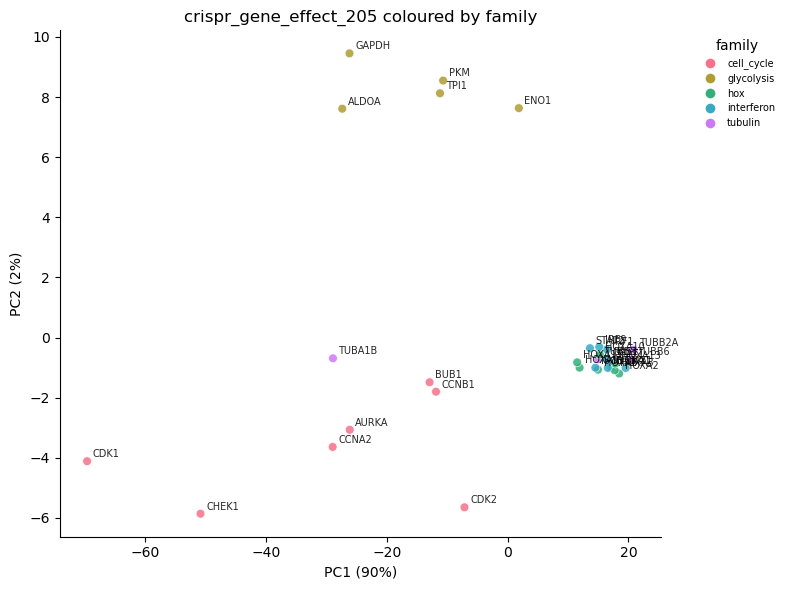

In [39]:
if best is not None:
    pl.plot_embedding_space(dense_space, obsm_key=spaces[best], method="pca",
                            color="family", annotate=True, annotate_col="symbol",
                            title=f"{best} coloured by family")

Comparing the two plots is the point, and they go in this order deliberately: the
first is coloured by the annotation count, the second by `family`, and both are
the same PCA of the same space.

`family` is the label the space was scored against. The annotation count is a
measured property nobody optimised for. If the *first* plot shows a gradient
running along the same axis that separates the classes in the *second*, the
embedding has picked up study bias -- well-annotated genes sitting together
because they are well annotated -- and not only biology.

That is an eyeball judgement, which is exactly what it should not stay. The next
section takes one of these `gene_*` columns as a regression target, fits four
plain probes on every embedding in turn and reports R2, so the gradient either
survives as a number or it does not.

## Reading a DNA model's attention

Everything so far used a pooled vector: one number per dimension for a whole
locus, with the positions averaged away. Attention is the opposite -- one number
per token pair, before any pooling -- so it says which parts of the input the
model routed information between.

For proteins that is unusually easy to read, because the tokens *are* amino acids
at known positions. For DNA it is not. Nucleotide Transformer v2 tokenises
**6-mers**, GENA-LM uses **BPE units of variable length**, and neither is a base,
a codon, or an exon. So a token index is not a coordinate, and every positional
statement below is approximate by construction. Where a mapping from tokens to
base pairs is needed, the section derives the bases-per-token factor from the
tokeniser's own output rather than assuming 6.

> **Structural, not causal.** Attention says what attends to what. Jain & Wallace
> (NAACL 2019, *Attention is not Explanation*) showed attention can be altered
> substantially without changing a model's predictions, so a high-attention token
> is not thereby shown to have driven the embedding. What follows is a structural
> readout worth checking against known biology -- not an explanation of the
> vector.

`get_model()` returns the wrapper rather than an array, and the wrapper exposes
the internals.

### Choosing a locus

Attention is quadratic: one block holds `heads x tokens x tokens` floats, and
`layers=None` asks for every block at once, so doubling the input quadruples every
one of those matrices. A multi-kilobase locus across a few dozen head-blocks runs
into gigabytes of tensors that exist only to be reduced to a couple of summary
statistics. The sensible input is therefore the *shortest* locus already resolved
by the [resolution section](#resolve-the-loci-and-measure-them-before-trusting-anything)
-- no new Ensembl calls and no new download.

The pick comes from that section's in-memory `exon_cache`, **not** from re-reading
`gene_exons.json`. The difference matters here more than anywhere else in the
notebook: the in-memory dict holds only genes whose exon count matched Ensembl's
canonical transcript, and a silently truncated gene is short. Picking the shortest
sequence out of the raw file is therefore the one selection rule most likely to
land on exactly the corrupted entry that section was written to catch.

One extra requirement: the readout further down compares the flanking exons
against the interior ones, which needs at least three exons to mean anything. So
the pick is the shortest validated sequence that has three or more exons, falling
back to the shortest sequence of any kind if none qualifies.

In [40]:
ATTN_MODEL = "nt_v2_100m"
MAX_ATTN_BP = 2000       # hard ceiling, so a large cache entry cannot blow up memory

# exon_cache and dna_genes come from the resolution section. Reusing them rather
# than re-reading gene_exons.json is deliberate: that dict was filtered to entries
# whose exon count matched Ensembl, and it is restricted to this panel.
usable = {g: exon_cache[g] for g in dna_genes if exon_cache[g].get("sequence")}
multi_exon = {g: rec for g, rec in usable.items() if int(rec.get("n_exons", 0)) >= 3}
pool = multi_exon or usable

ATTN_GENE = min(pool, key=lambda g: len(pool[g]["sequence"])) if pool else None
attn_sequence, exon_lengths = "", []

if ATTN_GENE is None:
    print("no panel gene carries a validated exon sequence -- the resolution section "
          "printed why; this whole attention section is skipped.")
else:
    record = pool[ATTN_GENE]
    attn_sequence = record["sequence"][:MAX_ATTN_BP]
    # Clip the exon lengths to whatever survived the truncation, so the boundaries
    # below still describe the string actually fed to the model.
    remaining = len(attn_sequence)
    for length in record.get("exon_lengths", []):
        if remaining <= 0:
            break
        take = min(int(length), remaining)
        exon_lengths.append(take)
        remaining -= take

    cached_lengths = list(record.get("exon_lengths", []))
    print(f"chose {ATTN_GENE}: shortest of {len(pool)} resolved "
          f"{'multi-exon ' if multi_exon else ''}loci, so the attention tensors stay small")
    print(f"  chromosome      : {record.get('chrom', '?')}")
    print(f"  exons           : {record.get('n_exons', len(cached_lengths))} "
          f"({', '.join(str(v) for v in cached_lengths)} bp)")
    print(f"  spliced length  : {len(record['sequence']):,} bp"
          + (f" -- truncated to {len(attn_sequence):,} bp at the {MAX_ATTN_BP:,} bp ceiling, "
             f"leaving {len(exon_lengths)} exon(s)"
             if len(attn_sequence) < len(record['sequence']) else ""))
    print(f"  genomic span    : {record.get('span', 0):,} bp "
          f"(the introns are not in the input; see the caveat below)")

chose GAPDH: shortest of 31 resolved multi-exon loci, so the attention tensors stay small
  chromosome      : 12
  exons           : 9 (53, 52, 100, 107, 91, 116, 82, 413, 271 bp)
  spliced length  : 1,285 bp
  genomic span    : 3,855 bp (the introns are not in the input; see the caveat below)


In [41]:
attn: dict = {}
tokens = None

if ATTN_GENE is not None:
    try:
        wrapper = embedder.get_model(ATTN_MODEL)
        tokens = wrapper.tokenizer(attn_sequence, return_tensors="pt")
        attn = wrapper.extract_attention(
            tokens["input_ids"],
            attention_mask=tokens["attention_mask"],
            layers=None,          # every block; pass e.g. [-1] for just the last
        )
    except Exception as exc:
        print(f"{ATTN_MODEL}: attention unavailable -- {type(exc).__name__}: {str(exc)[:160]}")

n_tokens = int(tokens["input_ids"].shape[1]) if attn else 0
last = max(attn) if attn else -1

if attn:
    print(f"{ATTN_GENE}: {len(attn_sequence):,} bp -> {n_tokens} tokens")
    print(f"implied bases per token : {len(attn_sequence) / n_tokens:.2f}  "
          "(6-mers, plus the special tokens counted in the total)")
    print(f"blocks returned         : {len(attn)}  (indices {min(attn)}..{last})")
    print(f"tensor shape            : {tuple(attn[last].shape)} = (batch, heads, seq, seq)")

    row_sums = attn[last].sum(-1).cpu().numpy()    # tensors come back on the model's device
    print(f"rows are distributions  : {bool(np.allclose(row_sums, 1.0, atol=1e-4))}")

GAPDH: 1,285 bp -> 216 tokens
implied bases per token : 5.95  (6-mers, plus the special tokens counted in the total)
blocks returned         : 22  (indices 0..21)
tensor shape            : (1, 16, 216, 216) = (batch, heads, seq, seq)
rows are distributions  : True


Every query row sums to 1: each token distributes a fixed budget of attention
over the sequence, so "receives a lot of attention" is always relative to the
other tokens of the same locus and never comparable in absolute terms across
inputs of different length.

> **Layer indexing.** `extract_attention` returns **one entry per transformer
> block** -- there is no embedding-layer entry, unlike `extract_hidden_states`
> where index 0 *is* the embedding layer. Mixing the two conventions silently
> shifts you one block; `tl.block_to_attention_index` and
> `tl.block_to_hidden_state_index` convert between them so the call site names
> the convention instead of assuming it.

### How focused is each head, and does that change with depth?

Entropy of a head's attention distribution: low means it concentrates on a few
tokens, high means it spreads out. The ceiling is `log(n_tokens)`, which is what
a head attending uniformly would score -- and which moves with sequence length,
so it is printed rather than assumed.

In [42]:
if not attn:
    depth = pd.DataFrame()
    print("no attention tensors -- depth profile skipped")
else:
    print(f"maximum possible entropy (uniform over {n_tokens} tokens): "
          f"{np.log(n_tokens):.2f}\n")

    profile = []
    for layer in sorted(attn):
        entropy = tl.attention_entropy(attn[layer])          # (batch, n_heads)
        profile.append({"block": layer,
                        "mean_entropy": float(entropy.mean()),
                        "most_focused": float(entropy.min()),
                        "most_diffuse": float(entropy.max()),
                        "specialisation": float(tl.head_uniformity(attn[layer]).mean())})

    depth = pd.DataFrame(profile).set_index("block")
    step = max(1, len(depth) // 8)                            # keep the table readable
    display(depth.round(3).iloc[::step])

maximum possible entropy (uniform over 216 tokens): 5.38



,mean_entropy,most_focused,most_diffuse,specialisation
block,,,,
0,5.315,5.299,5.330,0.133
2,5.145,5.032,5.229,0.251
4,4.915,4.535,5.137,0.357
6,4.200,3.131,5.038,0.574
8,3.663,0.153,5.160,0.599
10,4.000,0.822,4.859,0.599
12,3.943,0.492,5.109,0.551
14,3.830,2.139,5.014,0.602
16,3.892,0.870,5.075,0.586


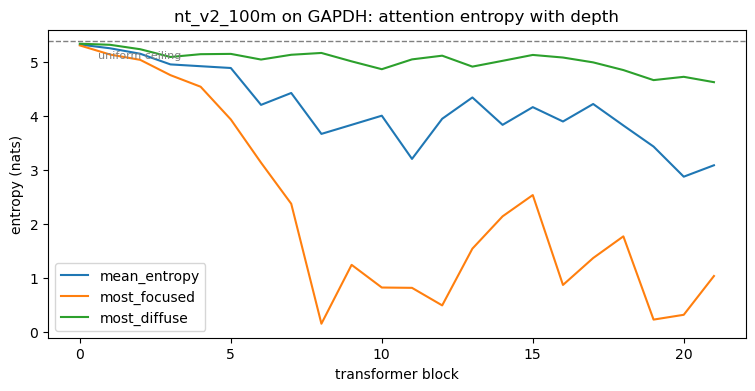

In [43]:
if len(depth):
    ax = depth[["mean_entropy", "most_focused", "most_diffuse"]].plot(
        figsize=(9, 4), title=f"{ATTN_MODEL} on {ATTN_GENE}: attention entropy with depth")
    ax.set_xlabel("transformer block")
    ax.set_ylabel("entropy (nats)")
    ax.axhline(np.log(n_tokens), ls="--", c="grey", lw=1)
    ax.annotate("uniform ceiling", xy=(0.5, np.log(n_tokens)),
                xytext=(2, -12), textcoords="offset points", fontsize=8, color="grey")

`head_uniformity` measures the same property on a fixed 0-1 scale (total-variation
distance to uniform), which is what makes it comparable across models and
sequence lengths -- entropy is not, because its ceiling is `log(n_tokens)` and
two tokenisers need not cut the same locus into the same number of tokens. The
GENA-LM comparison below leans on exactly that.

### Which parts of the locus does the model read?

`received_attention` sums the attention each token *receives*, head-averaged and
normalised so the values sum to 1 across tokens.

In [44]:
mass = None
if attn:
    mass = tl.received_attention(attn[last])[0]              # (n_tokens,)
    # .tolist() first: convert_ids_to_tokens wants plain ints, not a tensor.
    token_strings = wrapper.tokenizer.convert_ids_to_tokens(tokens["input_ids"][0].tolist())

    top = np.argsort(mass)[::-1][:12]
    print(f"{'token':>6}  {'k-mer':>10}  {'attention':>10}   (uniform would be "
          f"{1.0 / n_tokens:.5f})")
    for t in top:
        print(f"{int(t):>6}  {token_strings[int(t)]:>10}  {mass[int(t)]:>10.5f}")

 token       k-mer   attention   (uniform would be 0.00463)
    14      GGGGAA     0.00780
    70      GGGGGG     0.00730
    12      CTCAGA     0.00695
    60      GTACGT     0.00693
    10      CGAGCC     0.00657
    91      CTGCTT     0.00656
    41      ATTCCA     0.00638
     0       <cls>     0.00632
    37      CCAATA     0.00625
   114      GGCTCT     0.00614
     8      TGCGTC     0.00609
    18      CGGATT     0.00606


Read the k-mer column before reading anything into the ranking, and check where
the special tokens landed. The marker the tokeniser prepends is a convenient sink
for attention a head does not want to spend, and in transformer language models
it often draws a disproportionate share; where it does, that is a property of the
training objective rather than of this gene. The rest of the ranking is a list of
6-mers, which is as far as this model's tokens go -- they are not codons, they do
not respect reading frame, and consecutive tokens do not overlap.

### Mapping tokens back onto exons

The input was built by concatenating the exons of one gene, and the cache records
each exon's length, so the cumulative lengths give the exon boundaries in base
pairs. Converting a token index to a base-pair position needs a scale factor, and
the honest way to get it is from the tokeniser's own output: the number of
non-special tokens divided into the sequence length. Nucleotide Transformer
tokenises 6-mers, so the factor should come out near 6 -- the cell prints it, and
that printed value is where you check the assumption rather than make it.

Three caveats, all of which bound how far this can be pushed:

* **Token boundaries do not align with exon boundaries.** A 6-mer or a BPE unit
  straddles a junction whenever the exon length is not a multiple of the token
  length, so an exon's token set is right to within a token at each end.
* **The splice structure is an artefact of the input.** Concatenated exons contain
  no introns, so the junctions the model sees are not junctions in the genome --
  they are places where the sequence jumps by however many kilobases the intron
  spanned. A model trained on genomic sequence has never seen this input.
* **Position effects are confounded with the ends of the string.** The first and
  last exons are also the first and last tokens, and transformers attend
  differently at sequence boundaries regardless of content.

In [45]:
exon_table = pd.DataFrame()
if mass is not None and len(exon_lengths) >= 2:
    special = set(getattr(wrapper.tokenizer, "all_special_ids", []) or [])
    ids = tokens["input_ids"][0].tolist()
    seq_tokens = [i for i, t in enumerate(ids) if t not in special]
    bases_per_token = len(attn_sequence) / max(len(seq_tokens), 1)

    # Centre of each non-special token, in base pairs along the spliced sequence.
    token_bp = (np.arange(len(seq_tokens)) + 0.5) * bases_per_token
    ends = np.cumsum(exon_lengths)
    starts = np.concatenate([[0], ends[:-1]])

    print(f"{len(seq_tokens)} sequence tokens ({n_tokens - len(seq_tokens)} special), "
          f"{bases_per_token:.2f} bp per token")

    rows = []
    for i, (start, end) in enumerate(zip(starts, ends), start=1):
        picked = [seq_tokens[j] for j in np.flatnonzero((token_bp >= start) & (token_bp < end))]
        if not picked:
            continue
        share = float(mass[picked].sum())
        rows.append({"exon": i, "bp": int(end - start), "tokens": len(picked),
                     "attention_share": share, "per_token": share / len(picked)})

    # Named columns, so an exon list that mapped to no tokens at all still yields a
    # table rather than a KeyError on the index.
    exon_table = pd.DataFrame(rows, columns=["exon", "bp", "tokens",
                                             "attention_share", "per_token"])
    exon_table = exon_table.set_index("exon")
    exon_table["vs_uniform"] = exon_table["per_token"] * n_tokens
    display(exon_table.round(5))
    print("vs_uniform > 1 means the exon draws more attention per token than a flat "
          "distribution over all tokens -- specials included -- would give it.")
elif mass is not None:
    print(f"{len(exon_lengths)} exon(s) in the input -- the boundary mapping needs at "
          "least two, so it is skipped")

215 sequence tokens (1 special), 5.98 bp per token


,bp,tokens,attention_share,per_token,vs_uniform
exon,,,,,
1,53,9,0.04581,0.00509,1.09942
2,52,9,0.05453,0.00606,1.30863
3,100,16,0.06838,0.00427,0.92311
4,107,18,0.09137,0.00508,1.09645
5,91,15,0.06221,0.00415,0.89589
6,116,20,0.09215,0.00461,0.99526
7,82,14,0.07211,0.00515,1.11253
8,413,69,0.30958,0.00449,0.96911
9,271,45,0.19754,0.00439,0.94819


vs_uniform > 1 means the exon draws more attention per token than a flat distribution over all tokens -- specials included -- would give it.


In [46]:
if len(exon_table) >= 3:
    flanks = exon_table["per_token"].iloc[[0, -1]]
    interior = exon_table["per_token"].iloc[1:-1]
    ratio = float(flanks.mean() / interior.mean()) if interior.mean() else float("nan")
    print(f"first + last exon : {flanks.mean():.5f} per token")
    print(f"interior exons    : {interior.mean():.5f} per token  "
          f"({len(interior)} exon{'s' if len(interior) != 1 else ''})")
    print(f"ratio             : {ratio:.2f}x")
    print("\nA ratio far from 1 is as easily a sequence-boundary effect as a biological "
          "one -- the flanking exons are also the ends of the string. One gene cannot "
          "separate those; the same table over the whole panel could.")
elif len(exon_table):
    print(f"{len(exon_table)} exon(s) mapped -- too few to compare flanks against an interior.")

first + last exon : 0.00474 per token
interior exons    : 0.00483 per token  (7 exons)
ratio             : 0.98x

A ratio far from 1 is as easily a sequence-boundary effect as a biological one -- the flanking exons are also the ends of the string. One gene cannot separate those; the same table over the whole panel could.


### The same locus through a different tokeniser

GENA-LM is a BERT trained by a different group on a different corpus, and it
tokenises with BPE rather than fixed 6-mers. Running both on the same sequence
separates what is a property of the locus from what is a property of the
tokeniser.

The comparison has to be made carefully. Two tokenisers need not cut the same DNA
into the same number of tokens, and mean entropy is bounded by `log(n_tokens)`,
so a model with more tokens can score higher entropy while being *no less*
focused. `head_uniformity` is on a fixed 0-1 scale and is the column that stays
comparable whatever the token counts do; `entropy_vs_ceiling` divides the entropy
by its own ceiling for the same reason. The `tokens` and `entropy_ceiling`
columns are there so you can see how far apart the two scales actually are.

In [47]:
# Load a model, extract every block's attention, reduce it to scalars, then drop
# both the tensors and the checkpoint -- one model resident at a time, as in the
# embedding sweep.
def attention_summary(key: str, sequence: str) -> dict | None:
    try:
        w = embedder.get_model(key)
        tk = w.tokenizer(sequence, return_tensors="pt")
        a = w.extract_attention(tk["input_ids"], attention_mask=tk["attention_mask"],
                                layers=None)
    except Exception as exc:
        print(f"{key}: skipped -- {type(exc).__name__}: {str(exc)[:140]}")
        embedder.clear_model_cache()
        return None

    n = int(tk["input_ids"].shape[1])
    entropies = np.array([tl.attention_entropy(a[b]).mean() for b in sorted(a)])
    uniformity = np.array([tl.head_uniformity(a[b]).mean() for b in sorted(a)])
    summary = {
        "tokens": n,
        "bases_per_token": len(sequence) / n,
        "blocks": len(a),
        "heads": int(a[max(a)].shape[1]),
        "entropy_ceiling": float(np.log(n)),
        "mean_entropy": float(entropies.mean()),
        "entropy_vs_ceiling": float(entropies.mean() / np.log(n)),
        "mean_uniformity": float(uniformity.mean()),
        "uniformity_last_block": float(uniformity[-1]),
    }
    del a                      # a rank-4 tensor per block adds up; drop it early
    embedder.clear_model_cache()
    return summary


COMPARE_MODELS = [ATTN_MODEL, "gena_lm_bert_base"]
tokeniser_table = pd.DataFrame()

if ATTN_GENE is not None:
    summaries = {key: attention_summary(key, attn_sequence) for key in COMPARE_MODELS}
    summaries = {key: value for key, value in summaries.items() if value is not None}
    if summaries:
        tokeniser_table = pd.DataFrame(summaries).T
        display(tokeniser_table.round(3))

/Users/grpinto/Documents/embpy/.pixi/envs/default/lib/python3.13/site-packages/transformers/modeling_utils.py:1044: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


,tokens,bases_per_token,blocks,heads,entropy_ceiling,mean_entropy,entropy_vs_ceiling,mean_uniformity,uniformity_last_block
nt_v2_100m,216.0,5.949,22.0,16.0,5.375,4.152,0.772,0.51,0.733
gena_lm_bert_base,214.0,6.005,12.0,12.0,5.366,2.272,0.423,0.77,0.697


Read the `tokens` column before the entropy columns. Where the two token counts
are close, the ceilings are close and `mean_entropy` can be compared directly;
where they are not, it cannot, and only `entropy_vs_ceiling` and
`mean_uniformity` survive the comparison. The block and head counts differ too,
so a difference in `mean_uniformity` is a difference between two whole
architectures and corpora, not an isolated statement about attention.

Whether the two models agree about how selective their heads are is a question
about attention as a measurement rather than about this gene: agreement would
suggest the selectivity is a property of DNA language modelling in general,
disagreement that it belongs to the architecture or the training corpus. One gene
cannot settle that either way -- the loop above runs over any list of sequences,
which is how you would.

### The attention-free wall

Two of the five DNA architectures in the roster cannot answer any of the above,
and not because embpy has not got round to them. **HyenaDNA** replaces attention
with implicit long convolutions, and **Caduceus** is a bi-directional state-space
model. Neither builds a token-by-token attention matrix at any point in its
forward pass, so there is nothing to extract -- a hook cannot capture a tensor
that was never materialised.

They declare `has_attention = False`, and `extract_attention` fails immediately
with the reason instead of running a forward pass that cannot produce weights.
The check happens before the load guard, so it costs nothing: no weights are
downloaded to be told no.

In [48]:
for key in ["hyenadna_small_32k", "caduceus_ph_131k"]:
    try:
        w = embedder.get_model(key, load=False)          # no weights downloaded
        print(f"{key}: has_attention = {w.has_attention}")
        w.extract_attention(np.zeros((1, 8), dtype="int64"), layers=[-1])
        print(f"{key}: unexpectedly returned attention")
    except NotImplementedError as exc:
        print(f"{key} -> NotImplementedError: {exc}\n")
    except Exception as exc:
        print(f"{key} -> {type(exc).__name__}: {str(exc)[:160]}\n")

hyenadna_small_32k: has_attention = False
hyenadna_small_32k -> NotImplementedError: HyenaDNAWrapper wraps an architecture whose attention weights are not observable -- either it is attention-free (state-space, implicit convolution, graph message passing) or it computes attention with a fused kernel that never materialises the matrix. Use extract_hidden_states() for per-layer activations instead.

caduceus_ph_131k: has_attention = False
caduceus_ph_131k -> NotImplementedError: CaduceusWrapper wraps an architecture whose attention weights are not observable -- either it is attention-free (state-space, implicit convolution, graph message passing) or it computes attention with a fused kernel that never materialises the matrix. Use extract_hidden_states() for per-layer activations instead.



That message is the honest answer to "why can I not have attention here", and it
names the alternative: per-layer activations exist in every architecture,
attention-free or not, so `extract_hidden_states` is the readout to reach for
instead -- for HyenaDNA now, and for Caduceus once `mamba_ssm` is installed,
without which it cannot be loaded at all. The per-model reasoning is recorded in
[the attention-extraction reference](../attention_extraction.md).

### Keeping `has_attention` honest

`has_attention` is a class attribute, so it can be read without downloading
anything -- which is exactly what makes it useful as a capability check, and
exactly what makes a wrong value expensive.

The trap is the default. `BaseModelWrapper.has_attention` is `True`
(`src/embpy/models/base.py:51`), so a wrapper inherits the promise unless it opts
out. Four DNA wrappers used to inherit it while being unable to keep it:
`EnformerWrapper`, `BorzoiWrapper`, `EvoWrapper` and `Evo2Wrapper` are not
HuggingFace models, so `extract_attention` falls through to the forward-hook
path, which needs `_get_layer_modules()` -- and none of them overrides it. The
flag said `True`; the call raised. All four now declare `False` explicitly, with
the reason recorded next to the declaration:

* Enformer exposes no `blocks`/`layers` `ModuleList` for the hooks to find.
* Borzoi computes its attention eagerly but never *returns* it, and a forward
  hook can only observe what a module returns.
* Evo and Evo2 call FlashAttention, which computes the softmax inside the kernel,
  so the matrix never exists as a tensor.

The table below re-derives that from the classes themselves rather than repeating
it: for each wrapper it reads the flag and, beside it, whether the class declared
the flag itself and whether it overrides the hook entry point. All three are
class-level facts, so `load=False` answers them without a download.

In [49]:
FLAG_ROSTER = ["hyenadna_small_32k", "caduceus_ph_131k", "nt_v2_100m",
               "gena_lm_bert_base", "enformer_human_rough", "borzoi_v0"]

# Is `name` set anywhere below BaseModelWrapper, or only inherited from it?
def declared_by_subclass(cls, name: str) -> bool:
    return any(name in klass.__dict__ for klass in cls.__mro__
               if klass.__name__ != "BaseModelWrapper")

rows = []
for key in FLAG_ROSTER:
    try:
        w = embedder.get_model(key, load=False)
        cls = type(w)
        rows.append({"model": key, "wrapper": cls.__name__,
                     "has_attention": w.has_attention,
                     "flag_declared": declared_by_subclass(cls, "has_attention"),
                     "overrides_layer_modules": declared_by_subclass(cls, "_get_layer_modules")})
    except Exception as exc:
        rows.append({"model": key, "wrapper": "-", "has_attention": None,
                     "flag_declared": None, "overrides_layer_modules": None,
                     "wrapper_error": type(exc).__name__})

display(pd.DataFrame(rows).set_index("model"))
# The invariant: claiming attention requires a way to reach it. A row with
# has_attention=True, flag_declared=False and overrides_layer_modules=False is a
# wrapper that inherited the promise without anyone reviewing it -- the state all
# four non-HF DNA wrappers were in.
suspect = [r["model"] for r in rows
           if r.get("has_attention") and not r.get("overrides_layer_modules")
           and not r.get("flag_declared")]
print(f"\nwrappers claiming attention by inherited default: {suspect or 'none'}")
print("The cells above are the live test for Nucleotide Transformer and GENA-LM; "
      "the next cell is the live test for Enformer, whose declared False should now "
      "agree with what the call actually does.")

,wrapper,has_attention,flag_declared,overrides_layer_modules
model,,,,
hyenadna_small_32k,HyenaDNAWrapper,False,True,False
caduceus_ph_131k,CaduceusWrapper,False,True,False
nt_v2_100m,NucleotideTransformerWrapper,True,False,False
gena_lm_bert_base,GENALMWrapper,True,False,False
enformer_human_rough,EnformerWrapper,False,True,False
borzoi_v0,BorzoiWrapper,False,True,False



wrappers claiming attention by inherited default: ['nt_v2_100m', 'gena_lm_bert_base']
The cells above are the live test for Nucleotide Transformer and GENA-LM; the next cell is the live test for Enformer, whose declared False should now agree with what the call actually does.


The table is a claim about the classes; the next cell checks it against
behaviour. Enformer now declares `False`, so asking it for attention should fail
-- and a declared capability is only worth anything if the failure it predicts is
the failure you get. Its input is
not tokens but a one-hot tensor, built by the wrapper's own `_preprocess_sequence`
-- which also shows the other reason Enformer is the wrong model for this
notebook's inputs: it pads every input to 196,608 bp, so a spliced-exon sequence
of a couple of kilobases is almost entirely padding. Enformer wants a genomic
*window*, which is how [Variant effects](variant_effects.ipynb) uses it.

In [50]:
probe_sequence = attn_sequence or "ACGT" * 500

try:
    enformer = embedder.get_model("enformer_human_rough")
    one_hot = enformer._preprocess_sequence(probe_sequence)
    padding = 1 - len(probe_sequence) / enformer.SEQUENCE_LENGTH
    print(f"declared has_attention : {enformer.has_attention}")
    print(f"one-hot shape          : {tuple(one_hot.shape)}")
    print(f"input is {len(probe_sequence):,} bp of {enformer.SEQUENCE_LENGTH:,} "
          f"-> {padding:.2%} padding\n")
    enformer.extract_attention(one_hot, layers=[-1])
    print("extract_attention returned -- the flag was right after all")
except NotImplementedError as exc:
    print(f"NotImplementedError: {exc}")
except Exception as exc:
    print(f"{type(exc).__name__}: {str(exc)[:220]}")

declared has_attention : False
one-hot shape          : (1, 196608, 4)
input is 1,285 bp of 196,608 -> 99.35% padding

NotImplementedError: EnformerWrapper wraps an architecture whose attention weights are not observable -- either it is attention-free (state-space, implicit convolution, graph message passing) or it computes attention with a fused kernel that never materialises the matrix. Use extract_hidden_states() for per-layer activations instead.


The failure is explanatory -- it names the method a subclass would have to
override -- but note *when* it arrives: after the weights have been downloaded and
loaded, which is the cost `has_attention` exists to let you avoid. That is the
argument for the flag being correct rather than merely present, and it is why the
four inherited `True`s were worth changing.

Two habits survive the fix. Read `has_attention` before loading, since it is now
a reviewed claim for every DNA wrapper rather than a default for four of them.
And still wrap the extraction in a `try` for anything you have not run before: the
flag is a statement about the architecture, not a guarantee about your particular
checkpoint, tokeniser or `transformers` version. Every cell in this section does
both. The per-model reasoning is tracked in
[the attention-extraction reference](../attention_extraction.md).

In [51]:
# Attention tensors are the largest objects this notebook creates; drop them and
# the model cache before moving on.
if attn:
    del attn
embedder.clear_model_cache()

## Downstream: which model predicts a measured property?

Everything so far compared the models against each other, or against the panel
labels. A benchmark asks a different question: given this embedding, can a plain
regressor recover a number we measured independently? `tl.benchmark_embeddings`
trains four probes -- linear, ridge, k-NN, random forest -- on an embedding and
scores them against a target column in `.obs`.

The targets are chosen so that they should behave *differently*. A benchmark you
cannot fail is not a benchmark, and the interesting result here is the
**crossover**: the two model families should win on opposite targets.

| Target | Where it came from | Prior expectation |
| --- | --- | --- |
| `exon_len` | total exonic length, from the exon cache | **DNA models should win** -- these vectors are mean-pooled over tokens, and mean pooling is known to leak how many tokens there were |
| `n_exons` | exon count at the locus | same story but weaker -- exon count correlates with length rather than being readable off it |
| `gene_n_pathways` | pathway memberships from `annotate_gene_perturbations` | **knowledge tables should win** -- a lookup row distilled from literature, co-expression and screens is a record of what the gene *does*; a DNA model has never seen a pathway database |

Those are predictions, and the cells below score them. Whichever of the three
columns actually landed in `.obs` is used; a missing one is skipped rather than
faked.

Two things to hold on to while reading the numbers. R2 is on the standard scale
where 0 means "no better than predicting the mean", and **negative values mean
worse than that** -- a model scoring below zero on a target it should not be able
to reach is the correct answer, not a broken run. And the static tables should
land near zero on `exon_len` for a specific reason: a lookup row is keyed by gene
identity and carries nothing about the locus. If one of them does score, the
likely cause is a confound rather than sequence knowledge -- well-studied genes
tend to be both long and richly annotated.

A warning about the knowledge counts before they are used as a target. Only
`gene_n_pathways` is a genuine count. `gene_n_ppi_partners` and
`gene_n_disease_assoc` count what was *fetched*, and the fetch is capped -- the
STRING call passes `limit=DEFAULT_PPI_PARTNERS` and the Open Targets query
`size=DEFAULT_DISEASE_ASSOCIATIONS` -- so for any well-studied gene they report
the cap rather than a measurement. Measured across eight genes,
`gene_n_ppi_partners` was exactly 10 every time.

`annotate_gene_perturbations` now flags this rather than leaving you to notice it:
each capped column gets a companion `*_at_limit` boolean, and the caps themselves
are recorded in `.uns["gene_annotation_limits"]`. The selector below uses both --
it skips any candidate that is saturated for most genes, and any candidate with
fewer than three distinct values, and says which and why.

In [52]:
# dense_space, and not only because its rows are gap-free: the gene_* targets were
# written by the annotation cell in the previous section, which ran on dense_space.
# gene_space never received them.
bench_space = dense_space
pert_col = "symbol"

# Read the model -> obsm-key map built by the embedding sweep rather than iterating
# .obsm. That matters here: the PCA scatter plots earlier parked their 2-d
# coordinates in .obsm as X_pca_<key>, and a projection of a model is not a model.
# Benchmarking those would invent rows that look like results.
bench_spaces = {name: obsm for name, obsm in spaces.items() if obsm in bench_space.obsm}

# The crossover prediction is stated per family, so it has to be scored per family.
# DNA_KEYS and STATIC_KEYS are the rosters that actually produced vectors.
_dna, _static = set(DNA_KEYS), set(STATIC_KEYS)


def space_kind(name: str) -> str:
    if name in _dna:
        return "dna"
    if name in _static:
        return "static"
    return "other"


inventory = pd.DataFrame([
    {"model": name, "obsm_key": obsm, "kind": space_kind(name),
     "dim": int(np.asarray(bench_space.obsm[obsm]).shape[1]),
     "finite_rows": int(np.isfinite(
         np.asarray(bench_space.obsm[obsm], dtype=float)).all(axis=1).sum())}
    for name, obsm in bench_spaces.items()
]).set_index("model")

ignored = sorted(set(bench_space.obsm) - set(bench_spaces.values()))
print(f"benchmarking on dense_space: {bench_space.n_obs} genes, "
      f"{len(bench_spaces)} model spaces")
if ignored:
    print(f"ignored (derived coordinates, not embeddings): {ignored}")
display(inventory)

benchmarking on dense_space: 32 genes, 11 model spaces
ignored (derived coordinates, not embeddings): ['X_pca_X_crispr_gene_effect_1178', 'X_pca_X_crispr_gene_effect_205', 'X_pca_X_gena_lm_bert_base', 'X_pca_X_gene2vec', 'X_pca_X_genept', 'X_pca_X_genept_scaled', 'X_pca_X_hyenadna_small_32k', 'X_pca_X_nt_v2_100m', 'X_pca_X_omics', 'X_pca_X_pops', 'X_pca_X_wikicrow']


,obsm_key,kind,dim,finite_rows
model,,,,
genept,X_genept,static,3072,32
genept_scaled,X_genept_scaled,static,3072,32
gene2vec,X_gene2vec,static,200,32
crispr_gene_effect_1178,X_crispr_gene_effect_1178,static,1178,32
crispr_gene_effect_205,X_crispr_gene_effect_205,static,205,32
omics,X_omics,static,256,32
pops,X_pops,static,256,32
wikicrow,X_wikicrow,static,4096,32
hyenadna_small_32k,X_hyenadna_small_32k,dna,256,32


In [53]:
# Pick one target from each group, whichever candidate landed in .obs. The two
# sequence targets come from the exon cache; the knowledge target is whichever
# gene_* count the annotator managed to populate, since that call can partly fail.
TARGET_GROUPS = [
    ("length",    "dna",    ["exon_len"]),
    ("count",     "dna",    ["n_exons"]),
    ("knowledge", "static", ["gene_n_pathways", "gene_n_ppi_partners",
                             "gene_n_disease_assoc", "gene_n_transcription_factors"]),
]

TARGETS: list[tuple[str, str]] = []          # (column, which family should win)
for group, expected, candidates in TARGET_GROUPS:
    for col in candidates:
        if col not in bench_space.obs:
            continue
        values = pd.to_numeric(bench_space.obs[col], errors="coerce")
        if values.notna().sum() < 16 or values.nunique(dropna=True) < 3:
            print(f"{col}: present but not usable as a target "
                  f"({int(values.notna().sum())} numeric values, "
                  f"{int(values.nunique(dropna=True))} distinct) -- skipped")
            continue
        # A capped column is a lower bound, not a measurement. The annotator now
        # says so directly, so use that rather than inferring it from the spread.
        limit_col = f"{col}_at_limit"
        if limit_col in bench_space.obs:
            saturated = bench_space.obs[limit_col].astype(bool).mean()
            if saturated > 0.5:
                cap = bench_space.uns.get("gene_annotation_limits", {}).get(col)
                print(f"{col}: {saturated:.0%} of genes are at the fetch limit"
                      + (f" ({cap})" if cap else "")
                      + " -- a lower bound, not a count; skipped")
                continue
        TARGETS.append((col, expected))
        break
    else:
        print(f"no {group} target found (tried {', '.join(candidates)}) -- "
              "that section of the prediction goes unscored")

print("\ntargets:", ", ".join(f"{col} (expect {exp} ahead)" for col, exp in TARGETS) or "none")


targets: exon_len (expect dna ahead), n_exons (expect dna ahead), gene_n_pathways (expect static ahead)


In [54]:
# dense_space is already gap-free in every embedding, so the mask below normally
# drops nothing. It is not decoration: it also drops genes whose *target* is NaN,
# and if every DNA model had failed to load, dense_space would be the intersection
# of the lookup tables alone and would still contain unresolved genes with no
# exon_len. A NaN reaching a regressor is a crash, not a low score.
MIN_ROWS = 16          # under a 0.25 split this is four test points; less is not a score

benchmarks: dict[tuple[str, str], pd.DataFrame] = {}
rows_used: dict[tuple[str, str], int] = {}

for target, _expected in TARGETS:
    y = pd.to_numeric(bench_space.obs[target], errors="coerce").to_numpy(dtype=float)
    for name, obsm_key in bench_spaces.items():
        matrix = np.asarray(bench_space.obsm[obsm_key], dtype=float)
        ok = np.isfinite(matrix).all(axis=1) & np.isfinite(y)
        if int(ok.sum()) < MIN_ROWS:
            print(f"{target} / {name}: only {int(ok.sum())} complete genes -- skipped")
            continue
        sub = bench_space[ok].copy()
        sub.obs[target] = y[ok]                      # force a plain float column
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                benchmarks[(target, name)] = tl.benchmark_embeddings(
                    sub, perturbation_column=pert_col, perturbation_type="genetic",
                    target=target, obsm_key=obsm_key,
                    models=["linear", "ridge", "knn", "random_forest"],
                    mode="quick", test_size=0.25, random_state=0,
                )
            rows_used[(target, name)] = int(ok.sum())
        except Exception as exc:
            print(f"{target} / {name}: skipped -- {type(exc).__name__}: {str(exc)[:70]}")

best_r2 = pd.DataFrame({
    target: {name: benchmarks[(target, name)]["r2"].max()
             for name in bench_spaces if (target, name) in benchmarks}
    for target, _expected in TARGETS
}).dropna(how="all")

print("\nbest R2 over the four probes (rows = model, columns = target)")
display(best_r2.round(3))

counts = pd.DataFrame({
    target: {name: rows_used[(target, name)]
             for name in bench_spaces if (target, name) in rows_used}
    for target, _expected in TARGETS
}).dropna(how="all")
if not counts.empty and counts.min().min() != counts.max().max():
    print("genes used per cell -- these differ, so columns are not strictly comparable:")
    display(counts)
elif not counts.empty:
    print(f"every cell used the same {int(counts.max().max())} genes")


best R2 over the four probes (rows = model, columns = target)


,exon_len,n_exons,gene_n_pathways
genept,0.007,0.325,0.434
genept_scaled,-0.075,0.325,0.345
gene2vec,0.507,-0.360,-0.273
crispr_gene_effect_1178,0.001,-0.061,-0.370
crispr_gene_effect_205,0.127,-0.243,-0.391
omics,0.031,0.295,0.372
pops,0.532,0.329,0.366
wikicrow,0.240,0.401,0.160
hyenadna_small_32k,0.305,0.256,0.104
nt_v2_100m,0.820,-0.639,-0.925


every cell used the same 32 genes


In [55]:
# A positive R2 is not automatically signal. The panel is 40 genes, dense_space is
# whatever survived the gap mask, and a 0.25 split leaves a single-digit test set --
# so anything near zero is noise. Tier the verdict rather than reporting "beats the
# mean"; the thresholds are a judgement call, stated here so they can be argued with.
SIGNAL, NOISE = 0.30, 0.10

if best_r2.empty:
    print("no benchmark completed -- nothing to score")
else:
    per_target = pd.DataFrame({
        "best_r2": best_r2.max(),
        "best_model": best_r2.idxmax(),
        "worst_r2": best_r2.min(),
        "worst_model": best_r2.idxmin(),
    })
    display(per_target.round(3))

    for target, row in per_target.iterrows():
        r2, model = row["best_r2"], row["best_model"]
        below_mean = int((best_r2[target] < 0).sum())
        n_scored = int(best_r2[target].notna().sum())
        if r2 >= SIGNAL:
            verdict = f"real signal (R2={r2:.3f}, {model})"
        elif r2 >= NOISE:
            verdict = f"at the noise floor (R2={r2:.3f}, {model}) -- not a usable predictor"
        else:
            verdict = f"nothing usable (best R2={r2:.3f}, {model})"
        print(f"  {target:24s} {verdict}; "
              f"{below_mean}/{n_scored} models score below zero")

,best_r2,best_model,worst_r2,worst_model
exon_len,0.820,nt_v2_100m,-0.075,genept_scaled
n_exons,0.496,gena_lm_bert_base,-0.639,nt_v2_100m
gene_n_pathways,0.434,genept,-0.925,nt_v2_100m


  exon_len                 real signal (R2=0.820, nt_v2_100m); 1/11 models score below zero
  n_exons                  real signal (R2=0.496, gena_lm_bert_base); 4/11 models score below zero
  gene_n_pathways          real signal (R2=0.434, genept); 5/11 models score below zero


In [56]:
# Score the crossover prediction directly: per target, which family leads?
if not best_r2.empty:
    kinds = pd.Series({name: space_kind(name) for name in best_r2.index})
    by_kind = best_r2.groupby(kinds).mean()
    print("mean best-R2 by model family\n")
    display(by_kind.round(3))

    for target, expected in TARGETS:
        if target not in by_kind.columns:
            continue
        available = by_kind[target].dropna()
        if len(available) < 2:
            print(f"  {target:24s} only {list(available.index)} present -- not a contrast")
            continue
        leader = available.idxmax()
        held = "as predicted" if leader == expected else "CONTRARY to the prediction"
        margin = available.max() - available.min()
        print(f"  {target:24s} expected {expected:6s} ahead; {leader} leads "
              f"by {margin:.3f} -- {held}")

mean best-R2 by model family



,exon_len,n_exons,gene_n_pathways
dna,0.483,0.038,-0.297
static,0.171,0.126,0.081


  exon_len                 expected dna    ahead; dna leads by 0.312 -- as predicted
  n_exons                  expected dna    ahead; static leads by 0.088 -- CONTRARY to the prediction
  gene_n_pathways          expected static ahead; static leads by 0.378 -- as predicted


all four probes for nt_v2_100m predicting exon_len (32 genes, 8 held out):


,mse,r2,pearson,spearman,delta_l2_mae,delta_l2_pearson
model,,,,,,
linear,395222.366,0.663,0.884,0.905,NaN,NaN
ridge,349006.635,0.702,0.896,0.905,NaN,NaN
knn,211233.455,0.820,0.951,0.886,NaN,NaN
random_forest,445602.593,0.619,0.886,0.905,NaN,NaN


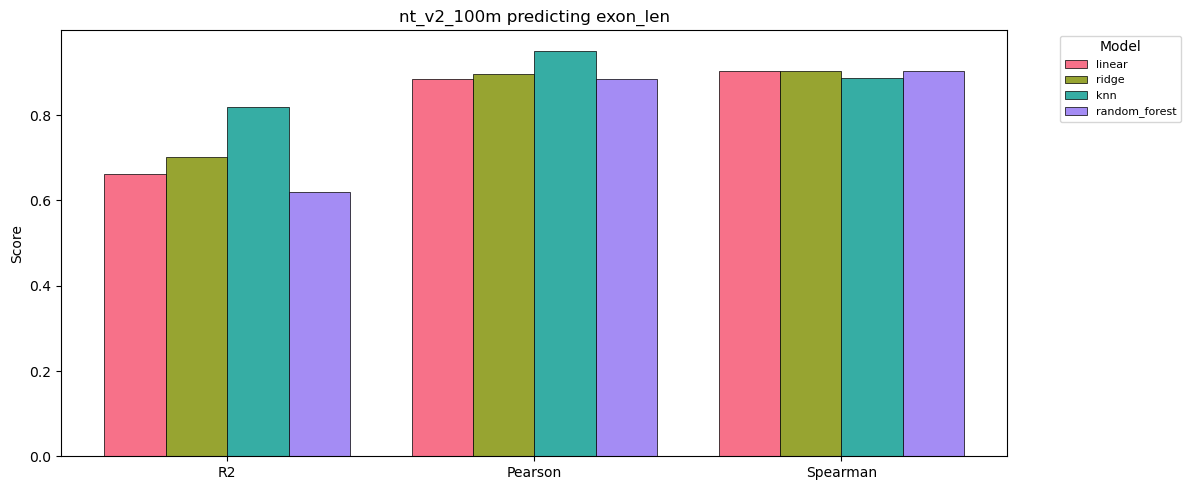

In [57]:
# Full per-probe detail for the single best (target, model) pair, plus the plot.
if benchmarks and not best_r2.empty:
    top_target = best_r2.max().idxmax()
    top_model = best_r2[top_target].idxmax()
    print(f"all four probes for {top_model} predicting {top_target} "
          f"({rows_used[(top_target, top_model)]} genes, "
          f"{int(round(0.25 * rows_used[(top_target, top_model)]))} held out):")
    display(benchmarks[(top_target, top_model)].round(3))
    pl.plot_benchmark(benchmarks[(top_target, top_model)],
                      title=f"{top_model} predicting {top_target}")

**Read the baseline, not the winner.** `benchmark_embeddings` trains a plain
linear probe alongside the rest, and that probe is the number to check first: a
space whose best result is no better than a linear read of its own vectors bought
you nothing for this task. A random forest beating linear by a wide margin is
usually telling you the relationship is non-linear, not that the embedding is
good.

**Treat these particular numbers as a demonstration, not a benchmark result.** The
cell above printed how many genes went in and how many were held out; at a panel of
40 and a gap-free subset smaller than that, a 25% split leaves a single-digit test
set. That is far too few for a stable R2, so the ordering between two close models
here is not information -- only the gap between a model near the signal threshold
and one below zero is. For a real decision use `mode="rigorous"` (5-fold CV with a
hyper-parameter search) and hold out whole families rather than random rows, so the
score measures generalisation instead of memorising which gene is which.

The length result, wherever it landed, is worth pausing on for a reason that
outlives this panel. Mean pooling averages over tokens, so a mean-pooled DNA
embedding carries a trace of how many tokens there were. If your real target
correlates with locus or transcript length -- expression level and mappability
both do -- a probe can score well by reading off length and learning nothing
about your biology. Regress length out, or stratify by it, before believing the
score.

`tl.__all__` also carries `phenotypic_activity`, the perturbation-screen readouts
(`delta_l2`, `deg_overlap`, `phenocopy_score`) and `compute_scib_metrics`. Those
need perturbation or single-cell data -- a control column in `.obs`, or batch and
cell-type labels -- which a panel of 40 gene identifiers does not have, so they
live in [cells](cells.ipynb).

## A calling-convention trap: `annotate_genes` is not `annotate_gene_perturbations`

Two functions in `tl` start with `annotate` and look interchangeable. They are
not, and the differences are the kind that fail quietly:

| | `annotate_gene_perturbations` | `annotate_genes` |
| --- | --- | --- |
| Reads identifiers from | `.obs[column]` -- you name the column | `.var_names`, unless you pass `query_ids` |
| Identifier type | inferred (symbols or Ensembl IDs) | fixed by `reference_id` |
| Returns | a modified **copy** by default (`copy=True`) | **`None`** |
| Writes | `gene_*` columns in `.obs`, full records in `.uns` | see below -- the cell measures it |
| Backed by | MyGene, GTEx, HPA, STRING, DoRothEA, Open Targets, GWAS | pertpy's `CellLine` LookUp |

The trap is the return value. `adata = tl.annotate_genes(adata, ...)` silently
replaces your AnnData with `None`, because this one mutates in place -- or does
not write at all. And the default axis is wrong for this notebook: our genes are
**rows**, so `.var_names` holds a placeholder and `query_ids` has to be passed
explicitly or the overlap check runs against nothing.

Rather than assert what it writes, the cell below diffs the object before and
after and prints whatever actually landed.

In [58]:
# Run on a copy: whatever this does, it should not touch the object the rest of
# the notebook is using. `annot_probe` rather than `annotated`, which the previous
# section already used for a flag.
annot_probe = bench_space.copy()
before_obs = set(annot_probe.obs.columns)
before_uns = set(annot_probe.uns)

try:
    returned = tl.annotate_genes(
        annot_probe,
        reference_id="hgnc_symbol",
        query_ids=list(annot_probe.obs[pert_col]),
    )
    new_obs = sorted(set(annot_probe.obs.columns) - before_obs)
    new_uns = sorted(set(annot_probe.uns) - before_uns)
    print(f"\nreturn value : {returned!r}   <- not an AnnData")
    print(f"new .obs cols: {new_obs or 'none'}")
    print(f"new .uns keys: {new_uns or 'none'}")
    if new_obs:
        display(annot_probe.obs[new_obs].head())
except Exception as exc:
    print(f"annotate_genes unavailable: {type(exc).__name__}: {str(exc)[:200]}")
    print("It goes through pertpy's CellLine LookUp, which downloads its metadata "
          "on first use -- an offline kernel fails here and loses nothing else.")

annotate_genes unavailable: ImportError: pertpy is required for metadata annotation. Install it with: pip install pertpy
It goes through pertpy's CellLine LookUp, which downloads its metadata on first use -- an offline kernel fails here and loses nothing else.


Read the two "new ... cols/keys" lines against the source. `annotate_genes` calls
pertpy's `LookUp.available_genes_annotation`, which *prints* a coverage report;
it does not assign to `.obs` or `.uns`, which is why the return value is `None`
and why the diff above is what it is. Treat it as a coverage check to run
**before** committing to an identifier type, and use
`annotate_gene_perturbations` -- which produced the `gene_*` columns benchmarked
above -- when you want annotations as data.

### The same class of trap, already sprung inside embpy

The resolution section flagged that `GeneResolver` is constructed with `species=`
while its own `get_gene_regions` takes `organism=`. That inconsistency is not
hypothetical. `embpy.embedder._resolve_gene_jump_fallback` -- the path that
canonicalises a gene symbol when a JUMP lookup misses -- constructs
`GeneResolver(organism="human")`, and the whole body sits inside a bare
`except Exception: pass`. If that call is a `TypeError`, the fallback returns
nothing and the MyGene.info alias lookup written below it never runs either.

Nothing in this notebook depends on that path. The cell is here because a
swallowed exception is invisible by design: the only way to find out is to call
the function and read what comes back against what the constructor accepts.

In [59]:
import inspect

from embpy.embedder import _resolve_gene_jump_fallback
from embpy.resources.gene.resolver import GeneResolver as _GeneResolver

try:
    jump_rows, jump_source = _resolve_gene_jump_fallback("TP53", return_source=True)
    accepted = [p for p in inspect.signature(_GeneResolver.__init__).parameters
                if p != "self"]
    body = inspect.getsource(_resolve_gene_jump_fallback)

    print(f"_resolve_gene_jump_fallback('TP53') -> {len(jump_rows)} rows, "
          f"source={jump_source!r}")
    print(f"GeneResolver.__init__ accepts             : {accepted}")
    print(f"fallback calls GeneResolver(organism=...) : "
          f"{'GeneResolver(organism=' in body}")
    print(f"...inside a bare 'except Exception'       : {'except Exception' in body}")
except Exception as exc:
    print(f"probe skipped -- {type(exc).__name__}: {str(exc)[:160]}")

_resolve_gene_jump_fallback('TP53') -> 0 rows, source=None
GeneResolver.__init__ accepts             : ['ensembl_release', 'species', 'auto_download', 'mart_file', 'chromosome_folder']
fallback calls GeneResolver(organism=...) : False
...inside a bare 'except Exception'       : True


Read the four lines together rather than any one of them. A row count of zero with
no source, from a function whose only job is to produce rows, next to a keyword the
constructor does not list, is a fallback that cannot fire. Dead code that returns a
valid-looking empty answer is worse than dead code that raises, because every caller
reads the empty answer as "no match found" -- which is also what a genuine miss
looks like.

## Variants, briefly

A gene embedding answers "what is this gene like". A variant asks something
narrower: what changes when one base changes. That is a different enough problem
to have [its own notebook](variant_effects.ipynb), which covers Borzoi's track
predictions, `SNPEmbedder` over real chromosomes, and profile scoring in depth.
This section only shows what exists and runs the mechanism once, so you know what
you are reaching for.

`embpy.tl.genomics` holds the variant utilities. Some are re-exported on `tl`
itself and some are not, which is worth checking rather than guessing -- the cell
below does exactly that.

| Name | What it is for |
| --- | --- |
| `SNPContext` | describes one variant: position, ref, alts, context window, strand |
| `SNPEmbedder` | embeds ref and alt contexts with any loaded DNA wrapper, returns deltas |
| `SNPEmbeddingResult` | the container -- ref/alt/delta vectors, `delta_norms`, cosine similarities |
| `SequenceProvider` | serves chromosome sequence from a per-chromosome FASTA directory, one indexed multi-record FASTA, or the Ensembl REST API -- in that preference order |
| `embed_vcf` | the batch path: a VCF path, a loaded wrapper, and a `chromosome_sequences` dict keyed by the VCF's CHROM column |
| `profile_variant_effect_score` | log2 fold-change over predicted coverage bins (the Borzoi statistic) |
| `genomic_to_bin_indices` | maps a genomic interval onto a track model's output bins |
| `download_hg38_per_chrom`, `download_hg38_single_fasta` | fetch the reference (~900 MB -- not run here) |

In [60]:
import embpy.tl.genomics as genomics

GENOMICS_API = ["SNPContext", "SNPEmbedder", "SNPEmbeddingResult", "SequenceProvider",
                "VariantEffectResult", "embed_vcf", "profile_variant_effect_score",
                "genomic_to_bin_indices", "download_hg38_per_chrom",
                "download_hg38_single_fasta"]

genomics_api = pd.DataFrame([
    {"name": name,
     "on embpy.tl.genomics": hasattr(genomics, name),
     "re-exported on tl": hasattr(tl, name)}
    for name in GENOMICS_API
]).set_index("name")
display(genomics_api)

submodule_only = list(genomics_api.index[~genomics_api["re-exported on tl"]])
print(f"reachable only by importing the submodule: {submodule_only or 'none'}")

,on embpy.tl.genomics,re-exported on tl
name,,
SNPContext,True,True
SNPEmbedder,True,True
SNPEmbeddingResult,True,True
SequenceProvider,True,True
VariantEffectResult,True,False
embed_vcf,True,True
profile_variant_effect_score,True,False
genomic_to_bin_indices,True,False
download_hg38_per_chrom,True,True


reachable only by importing the submodule: ['VariantEffectResult', 'profile_variant_effect_score', 'genomic_to_bin_indices']


Whatever that last line names is the practical point: `tl.__all__` re-exports part
of this API and not the rest, so a call written against `tl.` alone will work for
some of these names and raise `AttributeError` for others. Import
`embpy.tl.genomics` and you have all of it -- which is what the worked example
below does, so it does not depend on which names happen to be re-exported.

### One worked example, with no genome download

`SNPEmbedder.embed_snp` takes a plain sequence string and a 1-based position into
it. That string is normally a chromosome, but nothing requires it to be: the exon
sequence already cached in this notebook works as a **synthetic contig**, which
makes the mechanism runnable without the ~900 MB hg38 fetch.

The position and reference base are hard-coded and asserted against the cached
sequence. If the cache is ever rebuilt differently the assertion fires, the demo
is skipped with the mismatch printed, and nothing downstream reports a number --
rather than the cell quietly mutating whichever base happens to sit there and
presenting the result as a variant.

Be clear about what this is: a **mechanism demo on a synthetic contig**, not a
variant-effect result. The contig is spliced exons, so the variant has no
promoter, no splice sites and no intronic context around it -- exactly the
information a variant-effect model needs. Real work belongs in
[variant_effects.ipynb](variant_effects.ipynb).

In [61]:
# Read the exon cache from disk under its own name, so the resolution section's
# in-memory copy is left alone.
cache_path = OUTPUT_DIR / "gene_exons.json"
cached_exons = json.loads(cache_path.read_text()) if cache_path.exists() else {}

CONTIG_GENE, SNP_POS, SNP_REF, SNP_ALT = "TUBA1A", 800, "A", "G"

snp_result = None
try:
    contig = cached_exons[CONTIG_GENE]["sequence"].upper()
    # embed_vcf takes exactly this shape, keyed by the VCF's CHROM column.
    chromosome_sequences = {f"synthetic_{CONTIG_GENE}": contig}

    observed = contig[SNP_POS - 1]
    assert observed == SNP_REF, (
        f"{CONTIG_GENE} position {SNP_POS} is '{observed}', not '{SNP_REF}' -- "
        f"the cache changed; pick a new position"
    )

    hyena_wrapper = embedder.get_model("hyenadna_small_32k")
    snp = genomics.SNPContext(
        position=SNP_POS, ref_allele=SNP_REF, alt_alleles=[SNP_ALT],
        context_window=512, chrom=f"synthetic_{CONTIG_GENE}",
        variant_id=f"{CONTIG_GENE}:{SNP_POS}{SNP_REF}>{SNP_ALT}",
    )
    snp_embedder = genomics.SNPEmbedder(hyena_wrapper, pooling_strategy="mean")
    snp_result = snp_embedder.embed_snp(snp, chromosome_sequences[snp.chrom])

    print(f"contig: {len(contig)} bp of spliced {CONTIG_GENE} exons")
    print(f"window: {len(snp_result.ref_sequence)} bp centred on position {SNP_POS}")
    # to_dict() returns a list of rows, one per alt allele -- not a dict.
    display(pd.DataFrame(snp_result.to_dict()))
except Exception as exc:
    print(f"SNP demo skipped -- {type(exc).__name__}: {str(exc)[:300]}")

/Users/grpinto/.cache/huggingface/modules/transformers_modules/LongSafari/hyenadna-small-32k-seqlen-hf/8fe770c78eb13fe33bf81501612faeddf4d6f331/modeling_hyena.py:22: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [256, 514]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/Resize.cpp:38.)
  k_f = torch.fft.rfft(k.to(torch.float32), n=fft_size) / fft_size
/Users/grpinto/.cache/huggingface/modules/transformers_modules/LongSafari/hyenadna-small-32k-seqlen-hf/8fe770c78eb13fe33bf81501612faeddf4d6f331/modeling_hyena.py:23: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the 

contig: 1672 bp of spliced TUBA1A exons
window: 512 bp centred on position 800


,variant_id,chrom,position,ref,alt,delta_l2_norm,cosine_similarity,model,pooling
0,TUBA1A:800A>G,synthetic_TUBA1A,800,A,G,0.058231,0.999991,LongSafari/hyenadna-small-32k-seqlen-hf,mean


In [62]:
# A distance with no scale means nothing. Compare the one-base shift against the
# distances this same model puts between different genes.
if snp_result is not None:
    # From bench_spaces, not from .obsm directly: the PCA scatter plots left 2-d
    # coordinate arrays under X_pca_X_hyenadna_..., and a distance measured in
    # those would be a distance in a plot, not in the model's space.
    hyena_key = next((obsm for name, obsm in bench_spaces.items() if "hyenadna" in name), None)
    if hyena_key is None:
        print("no HyenaDNA panel space in .obsm -- the shift has no scale to be read against")
    else:
        from scipy.spatial.distance import pdist

        panel = np.asarray(bench_space.obsm[hyena_key], dtype=float)
        panel = panel[np.isfinite(panel).all(axis=1)]
        between = pdist(panel, metric="euclidean")
        shift = snp_result.delta_norms[0]

        print(f"one-base shift (ref -> alt)   : {shift:.4f}")
        print(f"closest two distinct genes    : {between.min():.4f}")
        print(f"median gene-gene L2           : {np.median(between):.4f}")
        print(f"ratio (shift / median gene-gene): {shift / np.median(between):.4f}")
        print(f"\ncosine(ref, alt) = {snp_result.cosine_similarities[0]:.6f}")
        print("Caveat: the panel vectors were pooled over the whole exon sequence and "
              "these two over a 512 bp window, so the ratio is indicative, not exact.")
embedder.clear_model_cache()

one-base shift (ref -> alt)   : 0.0582
closest two distinct genes    : 0.3629
median gene-gene L2           : 1.3533
ratio (shift / median gene-gene): 0.0430

cosine(ref, alt) = 0.999991
Caveat: the panel vectors were pooled over the whole exon sequence and these two over a 512 bp window, so the ratio is indicative, not exact.


Expect that ratio to be small, and the reason matters more than the number:
averaging over hundreds of token vectors dilutes a one-token change almost to
nothing. It is the same behaviour [proteins.ipynb](proteins.ipynb) measures for
point mutations, and it is a property of the pooling rather than evidence the
model is blind to the base -- the per-position representation at that site does
change, the mean just does not carry it.

So do not build a variant-effect score by diffing mean-pooled embeddings. Use a
model that predicts something measurable at the locus and score the *prediction*,
which is what `profile_variant_effect_score` does for Borzoi's coverage tracks,
and what [variant_effects.ipynb](variant_effects.ipynb) works through properly --
with real genomic context, on real chromosomes.

## Save the artifact

The full `gene_space` is written -- all 40 genes, NaNs and all, rather than
`dense_space`. The gaps are information: they record which genes each lookup table
has no row for, and dropping them here would force whoever reloads this file to
re-derive coverage. It also means the saved obsm keys are the raw model spaces
only; the PCA coordinates the plots produced live on `dense_space` and are not
worth persisting.

Sequence strings must not go in. Each is a few kilobases, they would dominate the
file, and they already exist in `gene_exons.json`. This notebook kept them in that
cache rather than in `.obs`, so the guard below usually finds nothing -- it is
there because parking the sequence in a column is the obvious thing to do when
adapting this notebook, and the resulting h5ad grows by an order of magnitude
without anyone noticing. What it keeps is the length, which is what downstream
analysis reads anyway.

In [63]:
OUTPUT_DIR.mkdir(exist_ok=True)
to_write = gene_space.copy()

# Any object-dtype column averaging over 200 characters is a sequence, not
# metadata. Keep the length, drop the string.
LONG_STRING = 200
for col in list(to_write.obs.columns):
    values = to_write.obs[col]
    if values.dtype != object:
        continue
    lengths = values.astype(str).str.len()
    if lengths.mean() > LONG_STRING:
        to_write.obs[f"{col}_bp"] = lengths.astype(int).to_numpy()
        to_write.obs = to_write.obs.drop(columns=[col])
        print(f"replaced obs['{col}'] with obs['{col}_bp'] "
              f"(max {int(lengths.max())} characters)")

path = OUTPUT_DIR / "gene_embeddings.h5ad"
written = False
try:
    to_write.write_h5ad(path)
    written = True
except (TypeError, ValueError) as exc:
    # h5ad needs every .uns leaf to be a writable type; nested annotation records
    # are the usual offender, so serialise them rather than silently drop them.
    print(f"first write failed ({type(exc).__name__}), serialising .uns: {str(exc)[:100]}")
    try:
        to_write.uns = {key: json.dumps(str(value)) for key, value in to_write.uns.items()}
        to_write.write_h5ad(path)
        written = True
    except Exception as exc2:
        print(f"still not writable -- {type(exc2).__name__}: {str(exc2)[:160]}")

if written:
    print(f"\nwrote {path} ({path.stat().st_size / 1e6:.1f} MB), {to_write.n_obs} genes")
    print(f"  obsm ({len(to_write.obsm)}): {', '.join(to_write.obsm)}")
    for key in to_write.obsm:
        matrix = np.asarray(to_write.obsm[key], dtype=float)
        gaps = int((~np.isfinite(matrix).all(axis=1)).sum())
        print(f"    {key:34s} {matrix.shape[1]:5d}d   "
              f"{'complete' if gaps == 0 else f'{gaps} gene(s) missing'}")
    print(f"  obs: {list(to_write.obs.columns)}")

    # An artifact you cannot read back is not an artifact.
    reloaded = ad.read_h5ad(path)
    assert reloaded.n_obs == gene_space.n_obs
    assert set(reloaded.obsm) == set(to_write.obsm)
    print(f"  round-trip OK: {reloaded.n_obs} genes, {len(reloaded.obsm)} embedding spaces")


wrote outputs/gene_embeddings.h5ad (2.6 MB), 40 genes
  obsm (11): X_genept, X_genept_scaled, X_gene2vec, X_crispr_gene_effect_1178, X_crispr_gene_effect_205, X_omics, X_pops, X_wikicrow, X_hyenadna_small_32k, X_nt_v2_100m, X_gena_lm_bert_base
    X_genept                            3072d   3 gene(s) missing
    X_genept_scaled                     3072d   complete
    X_gene2vec                           200d   complete
    X_crispr_gene_effect_1178           1178d   2 gene(s) missing
    X_crispr_gene_effect_205             205d   complete
    X_omics                              256d   complete
    X_pops                               256d   1 gene(s) missing
    X_wikicrow                          4096d   2 gene(s) missing
    X_hyenadna_small_32k                 256d   complete
    X_nt_v2_100m                         512d   complete
    X_gena_lm_bert_base                  768d   complete
  obs: ['symbol', 'family', 'coherence', 'has_sequence', 'exon_len', 'n_exons', 'locus_span'

  round-trip OK: 40 genes, 11 embedding spaces


## What we found

**The prediction.** The notebook opened with a claim: DNA sequence models should
recover the paralog families, because those families *are* shared sequence, and
should struggle on the pathway classes, because a pathway is a fact about function
that leaves no common signature in the DNA -- with the prior-knowledge tables doing
the reverse. The [interpretation section](#does-the-geometry-track-biology) scored
it with k-NN label purity against labels no model saw, and wrote its conclusion
into `PREDICTION_VERDICT`; the benchmark at the top of this section scored the same
split a second way, against numeric targets neither family was built for.

The cell below re-prints that verdict rather than paraphrasing it. A summary that
restated the number would stop being true the first time the panel, the roster or
Ensembl changed underneath it.

In [64]:
scored_verdict = globals().get("PREDICTION_VERDICT")
scored_deltas = globals().get("PREDICTION_DELTAS", {})

if scored_verdict is None:
    print("the interpretation section did not produce a verdict in this run -- "
          "re-run it; everything below still applies.")
else:
    print(scored_verdict)
    if scored_deltas:
        print("\nthe numbers behind it: " + "  ".join(
            f"{name}={value:.3f}" if isinstance(value, float) else f"{name}={value}"
            for name, value in scored_deltas.items()))

if not best_r2.empty:
    print(f"\nand from the benchmark above, best R2 per target:\n"
          f"{best_r2.max().round(3).to_string()}")

CONFIRMED: on the paralog families the DNA models gain 0.124 purity over their own score on the pathway classes, while the knowledge tables lose 0.097 -- opposite signs, which is the prediction. Each family is better at the classes its own evidence can see; the per-class table above says how far above the baseline each one still sits on its weak side.

the numbers behind it: dna_advantage=0.124  table_advantage=-0.097  purity_baseline=0.213  k=3  n_dna_models=3  n_table_models=8

and from the benchmark above, best R2 per target:
exon_len           0.820
n_exons            0.496
gene_n_pathways    0.434


What does not depend on how those numbers fell: the two model families are not
interchangeable, they fail on different things, and which one you want is settled
by your labels rather than by a leaderboard.

**Practical points, each of which cost something to learn here.**

1. **Fetch exons, not the locus.** `region="exons"` was not a stylistic choice.
   A gene's intronic span runs many times its exonic length -- the geometry table
   earlier measured the ratio for these genes -- so a whole-locus fetch is mostly
   intron, and at those lengths you are no longer comparing models, you are
   comparing how they truncate.
2. **Enformer is not a drop-in sequence encoder.** It centre-pads every input to
   196,608 bp, so a few kilobases of spliced exons arrive as overwhelmingly
   padding. It wants a genomic window; give it one, in
   [variant_effects.ipynb](variant_effects.ipynb).
3. **`missing="nan"` for lookup tables.** Coverage is not uniform across the
   static tables and the default is to fail on the first gene a table does not
   have. `missing="nan"` turns a fatal lookup into a gap you can see, count and
   decide about -- which is why the coverage table exists.
4. **The static catalogue and the data repository disagree in both directions.**
   `model_catalog("static")` lists `ccle`, `ccle_ensembl` and
   `crispr_gene_effect`, which the repository does not carry -- the probe cell in
   the embed section ran two of them and got `FileNotFoundError`. In the other
   direction, `string_functional_9606` and `string_node2vec_9606` are real files
   with no registry entry, so `embed()` raises `ModelNotFoundError` before it
   looks. The catalogue is generated from a source specification, not from the
   repository contents, and nothing checks that they agree. Probe a key on one
   gene before building a sweep on it.
5. **`clear_model_cache()` between models in a sweep.** embpy keeps loaded
   wrappers, which is right when you re-embed and wrong when you sweep: holding
   several DNA checkpoints resident at once buys nothing and is the easiest way
   to turn a sweep that would have fitted into an out-of-memory error.
6. **`has_attention` is trustworthy only for the HuggingFace-backed wrappers.**
   It is a class attribute defaulting to `True` on `BaseModelWrapper`, and only
   HyenaDNA and Caduceus override it to `False`. Enformer, Borzoi and the Evo
   wrappers inherit `True` while overriding no layer introspection, so they
   advertise a capability they do not have; the attention section demonstrates
   Enformer raising `NotImplementedError` after the weights have already loaded.
   Where it matters, the reliable check is to attempt the extraction and catch
   that exception.

**Where to go next.**

* [Comparing embeddings](03_compare_embeddings.ipynb) -- what each metric used
  here actually measures, and when they are allowed to disagree.
* [Reading a model's attention](06_attention_weights.ipynb) -- the
  extract-then-summarise pattern applied one step at a time, on smaller inputs.
* [Variant effects](variant_effects.ipynb) -- the proper version of the section
  above: Borzoi, real genomic context, and profile-based scoring.
* [Proteins](proteins.ipynb) -- the same programme for protein language models,
  where the sequence-versus-function tension resolves differently because the
  sequence *is* the functional unit.